# Testing horizons StrategyA

### IMPORTS

In [4]:
YEARS = [2022, 2023, 2024, 2025]

In [5]:
import sys, os
sys.path.insert(0, "/Users/HP/Documents/CODE_BOOK_4/THESIS_WORKING/THESIS_2")
sys.modules.pop("src", None)
os.chdir("/Users/HP/Documents/CODE_BOOK_4/THESIS_WORKING/THESIS_2")

In [6]:
import pandas as pd
import numpy as np
from math import sqrt, pi, exp
from arch import arch_model
import yfinance as yf 
from scipy.optimize import minimize
import warnings
from arch.__future__ import reindexing
from arch.utility.exceptions import ConvergenceWarning
from src.msGarch import msGARCH
from src.metrics import metrics
from src.msGarch import msGARCHIV
from tqdm import tqdm

from xgboost import XGBRegressor
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="y is poorly scaled")
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
import pyttsx3


In [7]:
def speak_done():
    engine = pyttsx3.init()
    engine.say("Cell completed")
    engine.runAndWait()
    engine.stop()
    

In [5]:
# import sys
# !{sys.executable} -m pip install xgboost

In [6]:
# # DO NOT RUN UNTIL CHANGES TO DEPENDENCIES 
# pip freeze > requirements.txt

### Load both data sets by year and quarter


In [8]:

# d_btc = pd.read_parquet("..\data\rawDatabtc_underlying_minutely_2022.parquet")
d_btc = pd.read_parquet("../data/rawData/btc_underlying_minutely_2022.parquet")
d_btc.set_index(pd.to_datetime(d_btc["date_time"]), inplace = True)

In [9]:
# Options with minutely data 
df = pd.read_parquet("../data/rawData/derivative_data_2022.parquet")

In [10]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/rawData")
YEARS = [2022, 2023, 2024, 2025]

d_btc_raw_by_year = {}
df_raw_by_year = {}

for y in YEARS:
    d_btc_raw_by_year[y] = pd.read_parquet(DATA_DIR / f"btc_underlying_minutely_{y}.parquet")
    df_raw_by_year[y]    = pd.read_parquet(DATA_DIR / f"derivative_data_{y}.parquet")


### Data Prep

In [ ]:

from src.dataPrep import dataprep

d_btc_by_year = {}
df_by_year = {}

for y in YEARS:
    d_btc = d_btc_raw_by_year[y]
    df    = df_raw_by_year[y]

    prep = dataprep(d_btc=d_btc, df=df)
    d_btc_by_year[y], df_by_year[y] = prep.run_all()


### Prepare MFIV 

In [ ]:
from src.interpol import MFIVPipeline

In [ ]:
from src.interpol import MFIVPipeline
import numpy as np
import pandas as pd

q = 0.0
HOURS = [5, 20, 30, 40]

X_by_year = {}
MFIV_by_year = {}

for y in YEARS:
    d_btc = d_btc_by_year[y].copy()
    df    = df_by_year[y]

    for H in HOURS:
        T = H / (24.0 * 365.0)
        d_btc[f"F{H}"] = d_btc["Close"] * np.exp((d_btc["rfr"] - q) * T)

    idx = d_btc.index.tz_localize("UTC") if d_btc.index.tz is None else d_btc.index.tz_convert("UTC")
    rt  = d_btc["r"].reindex(idx)

    pipe = MFIVPipeline(df=df, d_btc=d_btc, q=0.0)
    pipe.build_surfaces()
    MFIV_byH = pipe.compute_mfiv_byH(H_LIST=[5])

    mf = MFIV_byH[5].reindex(idx.tz_convert(None))
    bsiv = mf["bsIV"].to_numpy()
    mfiv = mf["MFIV"].to_numpy()

    X_by_year[y] = pd.DataFrame({"rt": rt.values, "bsIV": bsiv, "MFIV": mfiv}, index=idx)
    MFIV_by_year[y] = MFIV_byH


In [ ]:
from pathlib import Path

OUTDIR = Path("../data/readyData")
OUTDIR.mkdir(parents=True, exist_ok=True)

for y, X in X_by_year.items():
    X.to_parquet(OUTDIR / f"d_X_{y}.parquet")


###  Load parameters : X_by_year (NEXT : Load saved)

In [12]:

import pandas as pd
from pathlib import Path

INDIR = Path("../data/readyData")
YEARS = [2022, 2023, 2024, 2025]

X_by_year = {y: pd.read_parquet(INDIR / f"d_X_{y}.parquet") for y in YEARS}


In [13]:
X_by_year[2022]

,rt,bsIV,MFIV
date_time,,,
2021-12-31 23:00:00+00:00,NaN,NaN,NaN
2022-01-01 00:00:00+00:00,0.009782,NaN,NaN
2022-01-01 01:00:00+00:00,0.002855,NaN,NaN
2022-01-01 02:00:00+00:00,0.000406,NaN,NaN
2022-01-01 03:00:00+00:00,0.000085,3.834870,17.514097
...,...,...,...
2023-01-01 18:00:00+00:00,0.000392,NaN,NaN
2023-01-01 19:00:00+00:00,0.000693,2.942913,10.787206
2023-01-01 20:00:00+00:00,0.000603,5.000000,175.988572


In [14]:
import numpy as np

eps = 1e-12
for y, X in X_by_year.items():
    X_by_year[y][["bsIV","MFIV"]] = np.exp(
        np.log(X[["bsIV","MFIV"]].clip(lower=eps))
          .interpolate(method="time", limit_direction="both")
    )


In [15]:
# separated nested dict with year(2002) and quarters("q1") 
# X  : rt , bsIV , MFIV
Xq_by_year = {}

for y, X in X_by_year.items():
    Xq_by_year[y] = {
        "q1": X.loc[f"{y}-01-01":f"{y}-03-31 23:59:59"],
        "q2": X.loc[f"{y}-04-01":f"{y}-06-30 23:59:59"],
        "q3": X.loc[f"{y}-07-01":f"{y}-09-30 23:59:59"],
        "q4": X.loc[f"{y}-10-01":f"{y}-12-31 23:59:59"],
    }

# example: Xq_by_year[2025]["q1"]


In [16]:
Xq_by_year[2022]["q1"]

,rt,bsIV,MFIV
date_time,,,
2022-01-01 00:00:00+00:00,0.009782,3.834870,17.514097
2022-01-01 01:00:00+00:00,0.002855,3.834870,17.514097
2022-01-01 02:00:00+00:00,0.000406,3.834870,17.514097
2022-01-01 03:00:00+00:00,0.000085,3.834870,17.514097
2022-01-01 04:00:00+00:00,-0.002030,3.787864,30.529706
...,...,...,...
2022-03-31 19:00:00+00:00,-0.007949,1.013688,11.023218
2022-03-31 20:00:00+00:00,0.003567,0.001007,57.686731
2022-03-31 21:00:00+00:00,0.000371,0.000001,301.886347


In [17]:
# these are forecasts made by each model at t-1 aligned with t  
Xq_by_year[2022]["q1"].columns

Index(['rt', 'bsIV', 'MFIV'], dtype='str')

### Base Model (3 Regime MS-GARCH) 


In [ ]:
from src.msGarch import msGARCH
from src.msGarch import msGARCHIV
from src.LSTM_lib import LSTMGatedIVCorrection

In [ ]:
from src.msGarch import msGARCH
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm import tqdm
import numpy as np

quarters = [(y, q, Xq_by_year[y][q]) for y in YEARS for q in ["q1", "q2", "q3", "q4"]]

rolling_forecasts = {}
rolling_residuals = {}

idx_by_year = {}
f_rollB_by_year = {}
y_pred_by_year = {}
y_true_by_year = {}
regime_by_year = {}

for y, q, Xq in quarters:

    if y not in rolling_forecasts:
        rolling_forecasts[y] = {}
        rolling_residuals[y] = {}
        idx_by_year[y] = {}
        f_rollB_by_year[y] = {}
        y_pred_by_year[y] = {}
        y_true_by_year[y] = {}
        regime_by_year[y] = {}

    ms = msGARCH()
    prev_theta = ms.theta0.copy()

    regimeB, f_rollB, idx = [], [], []
    dt = Xq.index.tz_convert(None).to_pydatetime()
    Xn = Xq.to_numpy(dtype=float)

    for i in tqdm(range(10, len(Xn)), total=len(range(10, len(Xn))), desc=f"{y}_{q}"):

        r_sub = Xn[i-10:i, 0]
        mu = r_sub.mean()
        sigma = r_sub.std() or 1.0
        r_std = (r_sub - mu) / sigma

        res = minimize(
            ms.nll_ms_garch,
            prev_theta,
            args=(r_std, 3),
            method="L-BFGS-B",
            options={"maxiter": 300, "ftol": 1e-5}
        )

        theta_i = prev_theta if (not res.success or not np.isfinite(res.fun)) else res.x
        prev_theta = theta_i

        f_next, reg = ms.forecast_var_k(r_std, theta_i, R=3, k=1)
        f_next = f_next * (sigma**2)

        regimeB.append(reg[-1])
        f_rollB.append(f_next[-1])
        idx.append(i)

    f_rollB = np.array(f_rollB)
    idx = np.array(idx)

    x_plotB = dt[idx]
    y_true = Xn[idx, 0]**2

    idx_by_year[y][q] = idx
    f_rollB_by_year[y][q] = f_rollB
    rolling_forecasts[y][q] = f_rollB
    rolling_residuals[y][q] = y_true - f_rollB
    y_pred_by_year[y][q] = f_rollB
    y_true_by_year[y][q] = y_true
    regime_by_year[y][q] = regimeB

    plt.figure(figsize=(6, 3))
    plt.plot(x_plotB, y_true, label="Realized Var", linewidth=1)
    plt.plot(x_plotB, f_rollB, label="Rolling 1-Step Forecast", linewidth=1)
    plt.plot(x_plotB, np.array(regimeB)[:, 1] * 0.9 * plt.ylim()[1], color="black", alpha=0.6)
    plt.title(f"{y}_{q}")
    plt.tight_layout()
    plt.show()

In [ ]:
# import pickle

# save_dict = {
#     "idx_by_year": idx_by_year,
#     "f_rollB_by_year": f_rollB_by_year,
#     "rolling_forecasts": rolling_forecasts,
#     "rolling_residuals": rolling_residuals,
#     "y_pred_by_year": y_pred_by_year,
#     "y_true_by_year": y_true_by_year,
#     "regime_by_year": regime_by_year,
# }

# with open("../model_outputs_19_22/ms_garch_base_outputs.pkl", "wb") as f:
#     pickle.dump(save_dict, f)

### Base Model (3 Regime MS-GARCH) **vs** gated IV correction

In [92]:
import numpy as np
import torch
import torch.nn as nn
import numpy as np
import torch
import torch.nn as nn


class LSTMGatedIVCorrection(nn.Module):
    """
    ADDITIVE gated blend in LEVELS:
        h_hat_t = (1 - w_t) * h_base_t + w_t * h_iv_t

    To keep your caller code almost unchanged, predict() returns g_hat such that:
        h_final = h_base2 * np.exp(g_hat)
    matches the additive blend exactly by setting:
        g_hat_t = log( h_hat_t / h_base_t )
    """

    def __init__(self, hidden_dim=32, lr=1e-3, epochs=30, batch_size=256, seed=42, device=None):
        super().__init__()
        torch.manual_seed(seed)
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        # input: [bsIV, MFIV] -> LSTM -> gate w_t
        self.lstm = nn.LSTM(input_size=2, hidden_size=hidden_dim, batch_first=True)
        self.head = nn.Linear(hidden_dim, 1)

        self.to(self.device)
        self.last_w = None

    @staticmethod
    def _to_tensor(x, device):
        if isinstance(x, torch.Tensor):
            return x.to(device)
        return torch.tensor(x, dtype=torch.float32, device=device)

    def forward(self, X_seq):
        out, _ = self.lstm(X_seq)          # (B, T, H)
        hT = out[:, -1, :]                 # (B, H)
        w = torch.sigmoid(self.head(hT))   # (B, 1) in [0,1]
        return w

    def fit_xy(self, X_seq, rv, h_base2, h_iv2):
        """
        X_seq:   (N, SEQ_LEN, 2)
        rv:      (N, 1) or (N,) realized variance target in LEVELS (NOT logs)
        h_base2: (N,)    base variance aligned to the same N rows
        h_iv2:   (N,)    IV variance proxy aligned to the same N rows
        """
        X_seq = self._to_tensor(X_seq, self.device)

        rv = np.asarray(rv, float).reshape(-1)
        hb = np.asarray(h_base2, float).reshape(-1)
        hi = np.asarray(h_iv2,   float).reshape(-1)

        eps = 1e-12
        rv_t = self._to_tensor(rv.reshape(-1, 1), self.device)
        hb_t = self._to_tensor(np.maximum(hb, eps).reshape(-1, 1), self.device)
        hi_t = self._to_tensor(np.maximum(hi, eps).reshape(-1, 1), self.device)

        opt = torch.optim.Adam(self.parameters(), lr=self.lr)
        loss_fn = nn.MSELoss()

        N = X_seq.shape[0]
        for _ in range(self.epochs):
            perm = torch.randperm(N, device=self.device)
            for s in range(0, N, self.batch_size):
                ii = perm[s:s+self.batch_size]
                Xb, rvb, hbb, hib = X_seq[ii], rv_t[ii], hb_t[ii], hi_t[ii]

                w = self.forward(Xb)
                h_hat = (1.0 - w) * hbb + w * hib   # ADDITIVE blend in levels

                loss = loss_fn(h_hat, rvb)
                opt.zero_grad()
                loss.backward()
                opt.step()

        return self

    @torch.no_grad()
    def predict(self, X_seq, h_base2, h_iv2):
        """
        Returns g_hat so your existing caller line can stay:
            h_final = h_base2 * np.exp(g_hat)

        Internally we compute:
            h_hat = (1-w)*h_base + w*h_iv
            g_hat = log(h_hat / h_base)
        """
        X_seq = self._to_tensor(X_seq, self.device)

        hb = np.asarray(h_base2, float).reshape(-1)
        hi = np.asarray(h_iv2,   float).reshape(-1)

        eps = 1e-12
        hb_t = self._to_tensor(np.maximum(hb, eps).reshape(-1, 1), self.device)
        hi_t = self._to_tensor(np.maximum(hi, eps).reshape(-1, 1), self.device)

        w = self.forward(X_seq)
        self.last_w = w.detach().cpu().numpy()

        h_hat = (1.0 - w) * hb_t + w * hi_t
        g_hat = torch.log(torch.clamp(h_hat / hb_t, min=eps))

        return g_hat.detach().cpu().numpy()


In [ ]:
# Requires : idx_by_year[y][q], f_rollB_by_year[y][q]
# MS-GARCH base + LSTM correction (w IV) per quarter
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

quarters = [(y, q, Xq_by_year[y][q]) for y in YEARS for q in ["q1","q2","q3","q4"]]

h_final_byQ = {}
g_hat_byQ   = {}
w_byQ       = {}

tables_gatedIV = {}
rv2_gatedIV_by_year = {}
h_base2_gatedIV_by_year = {}

for y, q, Xq in quarters:

    idx_q    = np.asarray(idx_by_year [y][q], int)
    f_roll_q = np.asarray(f_rollB_by_year[y][q], float)

    t_idx  = Xq.index[idx_q]
    df_use = Xq.loc[t_idx, ["rt","bsIV","MFIV"]].copy()

    h_base_s = pd.Series(np.asarray(f_roll_q, float), index=t_idx)

    mask = df_use.notna().all(axis=1) & np.isfinite(h_base_s.values)
    df_use = df_use.loc[mask]
    h_base = h_base_s.loc[mask].to_numpy(float)

    rv = (df_use["rt"].to_numpy(float) ** 2)

    SEQ_LEN = 5
    feats = df_use[["bsIV","MFIV"]].to_numpy(np.float32)
    X_seq = []
    for i in range(SEQ_LEN, len(df_use)):
        X_seq.append(feats[i-SEQ_LEN:i])
    X_seq = torch.tensor(np.stack(X_seq))

    h_base2 = h_base[SEQ_LEN:]
    H = 5
    dt_years = H / (365.25 * 24.0)
    mfiv_H = np.maximum(df_use["MFIV"].shift(1).to_numpy(float) * dt_years, 1e-12)  # No lookahead

    scale = np.nanmedian(h_base2) / np.nanmedian(mfiv_H[SEQ_LEN:])
    h_iv2 = np.maximum(mfiv_H[SEQ_LEN:] * scale, 1e-12)

    rv2 = rv[SEQ_LEN:]

    g_hat = np.full(len(rv2), np.nan, dtype=float)
    last_w = None

    for t in range(1, len(rv2)):
        lstm_corr = LSTMGatedIVCorrection(hidden_dim=32, lr=1e-3, epochs=30, device="cpu").fit_xy(
            X_seq[:t], rv2[:t], h_base2[:t], h_iv2[:t]
        )
        g_hat[t] = lstm_corr.predict(X_seq[t:t+1], h_base2[t:t+1], h_iv2[t:t+1]).ravel()[0]
        last_w = getattr(lstm_corr, "last_w", None)

    h_base2 = h_base2[1:]
    h_iv2   = h_iv2[1:]
    rv2     = rv2[1:]
    g_hat   = g_hat[1:]
    h_final = h_base2 * np.exp(g_hat)

    if y not in h_final_byQ:
        h_final_byQ[y] = {}
        g_hat_byQ[y] = {}
        w_byQ[y] = {}
        tables_gatedIV[y] = {}
        rv2_gatedIV_by_year[y] = {}
        h_base2_gatedIV_by_year[y] = {}

    h_final_byQ[y][q] = h_final #  h is base forecast variance as numpy array
    g_hat_byQ[y][q]   = g_hat # g is predicted log correction term  |-|-|  g_hat ≈ log(rv / h_base)
    w_byQ[y][q]       = last_w

    x_plot2 = df_use.index[SEQ_LEN:][1:]

    rv2_gatedIV_by_year[y][q]     = rv2
    h_base2_gatedIV_by_year[y][q] = h_base2

    plt.figure(figsize=(6,3))
    plt.plot(x_plot2, rv2,     linewidth=1, label="Realized Var")
    plt.plot(x_plot2, h_base2, linewidth=1, label="MS-GARCH base")
    plt.plot(x_plot2, h_final, linewidth=1, label="MS-GARCH + gated IV correction")
    plt.title(f"{y}_{q}"); plt.legend(); plt.tight_layout(); plt.show()

    results = {}
    results["MS_base"]      = metrics(rv2, h_base2)
    results["MS_gatedIV"]   = metrics(rv2, h_final)

    table = pd.DataFrame(results, index=["RMSE","MAE","NLL","QLIKE","Bias"]).T.round(6)
    tables_gatedIV[y][q] = table
    print(f"{y}_{q}")
    print(table)
    

KeyError: 2019

In [ ]:
# # Check before running 
# import pickle

# save_dict = {
#     "h_final_byQ": h_final_byQ,
#     "g_hat_byQ": g_hat_byQ,
#     "w_byQ": w_byQ,
#     "tables_gatedIV": tables_gatedIV,
#     "rv2_gatedIV_by_year": rv2_gatedIV_by_year,
#     "h_base2_gatedIV_by_year": h_base2_gatedIV_by_year,
#     "quarters": quarters,
# }

# with open("../model_outputs_19_22/ms_garch_gatedIV_outputs.pkl", "wb") as f:
#     pickle.dump(save_dict, f)

### NoIV version LSTM forecast
 

In [63]:
quarters = [(y, q, Xq_by_year[y][q]) for y in YEARS for q in ["q1","q2","q3","q4"]]


In [64]:
from src.LSTM_lib import LSTMcorrNoIV

In [65]:

h_base2_noIV_by_year = {}
rv2_noIV_by_year = {}
h_final_noIV_by_year = {}

for y, q, Xq in quarters:

    if y not in h_base2_noIV_by_year:
        h_base2_noIV_by_year[y] = {}
        rv2_noIV_by_year[y] = {}
        h_final_noIV_by_year[y] = {}

    idx_q    = np.asarray(idx_by_year[y][q], int)
    f_roll_q = np.asarray(f_rollB_by_year[y][q], float)

    t_idx  = Xq.index[idx_q]
    df_use = Xq.loc[t_idx, ["rt"]].copy()

    h_base_s = pd.Series(f_roll_q, index=t_idx)

    mask = df_use["rt"].notna() & np.isfinite(h_base_s.values)
    df_use = df_use.loc[mask]
    h_base = h_base_s.loc[mask].to_numpy(float)

    rv = (df_use["rt"].to_numpy(float) ** 2)
    g  = np.log(rv + 1e-12) - np.log(h_base + 1e-12)

    SEQ_LEN = 5
    feats = df_use[["rt"]].to_numpy(np.float32)

    X_seq, y_seq = [], []
    for i in range(SEQ_LEN, len(df_use)):
        X_seq.append(feats[i-SEQ_LEN:i])
        y_seq.append(g[i])

    X_seq = torch.tensor(np.stack(X_seq))
    y_seq = torch.tensor(np.array(y_seq, np.float32)).view(-1, 1)

    g_hat = np.full(len(y_seq), np.nan, dtype=float)

    for t in range(1, len(y_seq)):
        lstm_corr = LSTMcorrNoIV(hidden_dim=32, lr=1e-3, epochs=30).fit_xy(X_seq[:t], y_seq[:t])
        g_hat[t] = lstm_corr.predict(X_seq[t:t+1])[0]

    h_base2 = h_base[SEQ_LEN:][1:]
    rv2     = rv[SEQ_LEN:][1:]
    h_final = h_base2 * np.exp(g_hat[1:])

    # store aligned outputs
    h_base2_noIV_by_year[y][q] = h_base2
    rv2_noIV_by_year[y][q]     = rv2
    h_final_noIV_by_year[y][q] = h_final


KeyError: 2019

In [ ]:
import pickle

save_dict_noIV = {
    "h_base2_noIV_by_year": h_base2_noIV_by_year,
    "rv2_noIV_by_year": rv2_noIV_by_year,
    "h_final_noIV_by_year": h_final_noIV_by_year,
    "quarters": quarters,
}

with open("../model_outputs_19_22/ms_garch_noIV_outputs.pkl", "wb") as f:
    pickle.dump(save_dict_noIV, f)
    


### Crucial check

In [37]:
print(idx_by_year.keys())

dict_keys([2019, 2020, 2021])


### Load Saved MSGarch Outputs (NEXT : Main Index)

In [18]:

#LOAD BASE 
import pickle
globals().update(pickle.load(open("../model_outputs_22_25/ms_garch_base_outputs.pkl","rb")))


In [19]:
# [k for k in globals() if not k.startswith("__") and not k.startswith("_") and not k.startswith("get") and not k.startswith("exit")
#  and not k.startswith("pickle") and not k.startswith("In") and not k.startswith("Out")]

In [20]:

#LOAD BASE 
import pickle
globals().update(pickle.load(open("../model_outputs_22_25/ms_garch_gatedIV_outputs.pkl","rb")))


In [21]:
# [k for k in globals() if not k.startswith("__") and not k.startswith("_") and not k.startswith("get") and not k.startswith("exit")
#  and not k.startswith("pickle") and not k.startswith("In") and not k.startswith("Out")]

In [22]:

#LOAD BASE 
import pickle
globals().update(pickle.load(open("../model_outputs_22_25/ms_garch_noIV_outputs.pkl","rb")))

In [23]:
# [k for k in globals() if not k.startswith("__") and not k.startswith("_") and not k.startswith("get") and not k.startswith("exit")
#  and not k.startswith("pickle") and not k.startswith("In") and not k.startswith("Out")]

In [22]:
[k for k in globals() if k.startswith("rv")]

['rv2_gatedIV_by_year', 'rv2_noIV_by_year']

In [23]:
Xq_by_year[2022]

{'q1':                                  rt      bsIV        MFIV
 date_time                                                
 2022-01-01 00:00:00+00:00  0.009782  3.834870   17.514097
 2022-01-01 01:00:00+00:00  0.002855  3.834870   17.514097
 2022-01-01 02:00:00+00:00  0.000406  3.834870   17.514097
 2022-01-01 03:00:00+00:00  0.000085  3.834870   17.514097
 2022-01-01 04:00:00+00:00 -0.002030  3.787864   30.529706
 ...                             ...       ...         ...
 2022-03-31 19:00:00+00:00 -0.007949  1.013688   11.023218
 2022-03-31 20:00:00+00:00  0.003567  0.001007   57.686731
 2022-03-31 21:00:00+00:00  0.000371  0.000001  301.886347
 2022-03-31 22:00:00+00:00  0.000819  0.000852   77.780133
 2022-03-31 23:00:00+00:00 -0.006403  0.725306   20.039823
 
 [2160 rows x 3 columns],
 'q2':                                  rt      bsIV        MFIV
 date_time                                                
 2022-04-01 00:00:00+00:00  0.000549  0.000852   14.713764
 2022-04-01 01:0

### outputs_by_year

In [24]:
# NEW CELL
# Rebuilds and stores the aligned plotting index `x_plot2`
#   for each year and quarter without rerunning the model.
# Uses idx_by_year to align the forecasts to forecasting index.
x_plot2_by_year = {}

for y in YEARS:
    x_plot2_by_year[y] = {}
    for q in ["q1", "q2", "q3", "q4"]:
        Xq = Xq_by_year[y][q]

        idx_q = np.asarray(idx_by_year[y][q], int)
        f_roll_q = np.asarray(f_rollB_by_year[y][q], float)

        t_idx = Xq.index[idx_q]
        df_use = Xq.loc[t_idx, ["rt"]].copy()

        h_base_s = pd.Series(f_roll_q, index=t_idx)

        mask = df_use["rt"].notna() & np.isfinite(h_base_s.values)
        df_use = df_use.loc[mask]

        x_plot2_by_year[y][q] = df_use.index[5:][1:]

In [25]:
print(YEARS)
print(idx_by_year.keys())

[2022, 2023, 2024, 2025]
dict_keys([2022, 2023, 2024, 2025])


In [26]:
x_plot2_by_year = {}

for y in YEARS:
    if y not in idx_by_year or y not in f_rollB_by_year:
        print(f"Skipping year {y}: missing in saved results")
        continue

    x_plot2_by_year[y] = {}

    for q in ["q1", "q2", "q3", "q4"]:
        if q not in idx_by_year[y] or q not in f_rollB_by_year[y]:
            print(f"Skipping {y} {q}: missing quarter data")
            continue

        Xq = Xq_by_year[y][q]
        idx_q = np.asarray(idx_by_year[y][q], int)
        f_roll_q = np.asarray(f_rollB_by_year[y][q], float)

        t_idx = Xq.index[idx_q]
        df_use = Xq.loc[t_idx, ["rt"]].copy()

        h_base_s = pd.Series(f_roll_q, index=t_idx)

        mask = df_use["rt"].notna() & np.isfinite(h_base_s.values)
        df_use = df_use.loc[mask]

        x_plot2_by_year[y][q] = df_use.index[5:][1:]

In [29]:
[k for k in globals() if k.startswith("h_final")]

['h_final_byQ', 'h_finalB_by_year']

In [31]:
import pandas as pd

outputs_by_year = {
    y: {
        q: pd.DataFrame(
            {
                "rv": rv2_gatedIV_by_year[y][q],
                "ms_base": h_base2_gatedIV_by_year[y][q],
                "ms_LSTM_noIV": h_finalB_by_year[y][q],
                "ms_LSTM_wIV": h_final_byQ[y][q],
            },
            index=x_plot2_by_year[y][q]
        )
        for q in ["q1", "q2", "q3", "q4"]
    }
    for y in YEARS
}

In [32]:
# Check this in the 19-25 variant of the same. its wrong. the above is copied from D_StrategyMSG.ipynb
# import pandas as pd

# outputs_by_year = {
#     y: {
#         q: pd.DataFrame(
#             {
#                 "rv": rv2_gatedIV_by_year[y][q],
#                 "ms_base": h_base2_gatedIV_by_year[y][q],
#                 "ms_LSTM_noIV": h_final_noIV_by_year[y][q],
#                 "ms_LSTM_wIV": h_final_byQ[y][q],
#             },
#             index=x_plot2_by_year[y][q]
#         )
#         for q in ["q1", "q2", "q3", "q4"]
#     }
#     for y in YEARS
# }

In [43]:
outputs_by_year[2022]['q1']

,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV
date_time,,,,
2022-01-01 16:00:00+00:00,8.468786e-07,0.000024,0.000027,0.000026
2022-01-01 17:00:00+00:00,1.051803e-04,0.000018,0.000011,0.000029
2022-01-01 18:00:00+00:00,1.579351e-05,0.000030,0.000026,0.000029
2022-01-01 19:00:00+00:00,2.513722e-05,0.000038,0.000028,0.000037
2022-01-01 20:00:00+00:00,4.102083e-06,0.000040,0.000028,0.000043
...,...,...,...,...
2022-03-31 19:00:00+00:00,6.318568e-05,0.000044,0.000036,0.000039
2022-03-31 20:00:00+00:00,1.272611e-05,0.000050,0.000032,0.000034
2022-03-31 21:00:00+00:00,1.378822e-07,0.000048,0.000040,0.000063


In [41]:
quarters = [(y, q, Xq_by_year[y][q]) for y in YEARS for q in ["q1", "q2", "q3", "q4"]]

### AR10

In [42]:
def estimate_ar10(Xq):
    f_rollB, y_true, idx = [], [], []
    Xn = Xq.to_numpy(dtype=float)

    for i in range(10, len(Xn)):
        r_sub = Xn[i-10:i, 0]

        phi = r_sub.mean()
        f_next = phi

        f_rollB.append(f_next)
        y_true.append(Xn[i, 0])
        idx.append(i)

    return np.array(f_rollB), np.array(y_true), np.array(idx)

In [44]:
for y, q, Xq in quarters:

    Xq_df = Xq_by_year[y][q]
    dt = Xq_df.index.tz_convert(None).to_pydatetime()

    f_rollB, y_true, idx = estimate_ar10(Xq_df)
    x_plotB = dt[idx]

    idx_by_year[y][q] = idx
    f_rollB_by_year[y][q] = f_rollB
    rolling_forecasts[y][q] = f_rollB
    rolling_residuals[y][q] = y_true - f_rollB
    y_pred_by_year[y][q] = f_rollB
    y_true_by_year[y][q] = y_true

In [45]:
for y in YEARS:
    for q in ["q1", "q2", "q3", "q4"]:
        outputs_by_year[y][q]["ar10"] = pd.Series(
            f_rollB_by_year[y][q],
            index=Xq_by_year[y][q].index[idx_by_year[y][q]]
        )

### GARCH

In [46]:
from arch import arch_model
import numpy as np
import matplotlib.pyplot as plt

def estimate_garch(Xq):
    f_rollB, y_true, idx = [], [], []
    Xn = Xq.to_numpy(dtype=float)

    for i in range(10, len(Xn)):
        r_sub = Xn[i-10:i, 0]

        am = arch_model(r_sub, mean="Constant", vol="GARCH", p=1, q=1, rescale=False)
        res = am.fit(disp="off", show_warning=False)

        f_next = res.forecast(horizon=1).variance.values[-1, 0]

        f_rollB.append(f_next)
        y_true.append(Xn[i, 0] ** 2)
        idx.append(i)

    return np.array(f_rollB), np.array(y_true), np.array(idx)

In [47]:

quarters = [(y, q, Xq_by_year[y][q]) for y in YEARS for q in ["q1", "q2", "q3", "q4"]]

rolling_forecasts = {}
rolling_residuals = {}

idx_by_year = {}
f_rollB_by_year = {}
y_pred_by_year = {}
y_true_by_year = {}
regime_by_year = {}

for y, q, Xq in quarters:

    if y not in rolling_forecasts:
        rolling_forecasts[y] = {}
        rolling_residuals[y] = {}
        idx_by_year[y] = {}
        f_rollB_by_year[y] = {}
        y_pred_by_year[y] = {}
        y_true_by_year[y] = {}

    Xq_df = Xq_by_year[y][q]
    dt = Xq_df.index.tz_convert(None).to_pydatetime()

    f_rollB, y_true, idx = estimate_garch(Xq_df)
    x_plotB = dt[idx]

    idx_by_year[y][q] = idx
    f_rollB_by_year[y][q] = f_rollB
    rolling_forecasts[y][q] = f_rollB
    rolling_residuals[y][q] = y_true - f_rollB
    y_pred_by_year[y][q] = f_rollB
    y_true_by_year[y][q] = y_true

    # plt.figure(figsize=(6, 3))
    # plt.plot(x_plotB, y_true, label="Realized Var", linewidth=1)
    # plt.plot(x_plotB, f_rollB, label="Rolling 1-Step Forecast", linewidth=1)
    # plt.title(f"{y}_{q}")
    # plt.tight_layout()
    # plt.show()

In [48]:
outputs_by_year[2022]['q2']

,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV,ar10
date_time,,,,,
2022-04-01 16:00:00+00:00,1.135240e-04,0.000029,0.000031,0.000042,0.004142
2022-04-01 17:00:00+00:00,8.196678e-05,0.000223,0.000325,0.000127,0.002745
2022-04-01 18:00:00+00:00,8.966245e-06,0.000047,0.000056,0.000048,0.003219
2022-04-01 19:00:00+00:00,4.186425e-07,0.000090,0.000060,0.000060,0.002602
2022-04-01 20:00:00+00:00,1.971838e-05,0.000054,0.000038,0.000039,0.002800
...,...,...,...,...,...
2022-06-30 19:00:00+00:00,5.530926e-06,0.000102,0.000078,0.000111,-0.001415
2022-06-30 20:00:00+00:00,8.703665e-05,0.000076,0.000070,0.000054,-0.001163
2022-06-30 21:00:00+00:00,1.598043e-05,0.000122,0.000081,0.000191,-0.001881


In [49]:
for y in YEARS:
    for q in ["q1", "q2", "q3", "q4"]:
        outputs_by_year[y][q]["garch"] = pd.Series(
            f_rollB_by_year[y][q],
            index=Xq_by_year[y][q].index[idx_by_year[y][q]]
        )

In [51]:
outputs_by_year[2022]['q2']

,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV,ar10,garch
date_time,,,,,,
2022-04-01 16:00:00+00:00,1.135240e-04,0.000029,0.000031,0.000042,0.004142,0.000024
2022-04-01 17:00:00+00:00,8.196678e-05,0.000223,0.000325,0.000127,0.002745,0.000067
2022-04-01 18:00:00+00:00,8.966245e-06,0.000047,0.000056,0.000048,0.003219,0.000070
2022-04-01 19:00:00+00:00,4.186425e-07,0.000090,0.000060,0.000060,0.002602,0.000051
2022-04-01 20:00:00+00:00,1.971838e-05,0.000054,0.000038,0.000039,0.002800,0.000059
...,...,...,...,...,...,...
2022-06-30 19:00:00+00:00,5.530926e-06,0.000102,0.000078,0.000111,-0.001415,0.000045
2022-06-30 20:00:00+00:00,8.703665e-05,0.000076,0.000070,0.000054,-0.001163,0.000030
2022-06-30 21:00:00+00:00,1.598043e-05,0.000122,0.000081,0.000191,-0.001881,0.000031


In [52]:
#temporary
import pickle
pickle.dump(outputs_by_year, open("../outputs_by_year/2022_2025/outputs_by_year_5mdls.pkl", "wb"))

In [ ]:
import pickle
outputs_by_year = pickle.load(open("../outputs_by_year/2022_2025/outputs_by_year_5mdls.pkl", "rb"))

### XGBoost

In [53]:
from xgboost import XGBRegressor
import numpy as np

def estimate_xgboost(Xq_df, target_col="rv", lookback=10):
    f_rollB = []
    y_true = []
    idx = []

    for t in range(lookback, len(Xq_df)):
        train = Xq_df.iloc[t - lookback:t]
        test = Xq_df.iloc[[t]]

        X_train = train.drop(columns=[target_col])
        y_train = train[target_col]

        X_test = test.drop(columns=[target_col])
        y_test = test[target_col].iloc[0]

        model = XGBRegressor(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.05,
            objective="reg:squarederror",
            random_state=42
        )
        model.fit(X_train, y_train)

        pred = model.predict(X_test)[0]

        f_rollB.append(pred)
        y_true.append(y_test)
        idx.append(t)

    return np.array(f_rollB), np.array(y_true), np.array(idx)

In [54]:
YEARS = [2022, 2023, 2024, 2025]
# YEARS = [2019, 2020, 2021]

In [55]:
for y in YEARS:
    for q in ["q1", "q2", "q3", "q4"]:
        Xq_by_year[y][q]["rv"] = Xq_by_year[y][q]["rt"] ** 2

In [56]:
quarters = [(y, q, Xq_by_year[y][q]) for y in YEARS for q in ["q1", "q2", "q3", "q4"]]

rolling_forecasts = {}
rolling_residuals = {}

idx_by_year = {}
f_rollB_by_year = {}
y_pred_by_year = {}
y_true_by_year = {}
regime_by_year = {}

for y, q, Xq in quarters:

    if y not in rolling_forecasts:
        rolling_forecasts[y] = {}
        rolling_residuals[y] = {}
        idx_by_year[y] = {}
        f_rollB_by_year[y] = {}
        y_pred_by_year[y] = {}
        y_true_by_year[y] = {}

    Xq_df = Xq_by_year[y][q]
    dt = Xq_df.index.tz_convert(None).to_pydatetime()

    f_rollB, y_true, idx = estimate_xgboost(Xq_df, target_col="rv", lookback=10)
    x_plotB = dt[idx]

    idx_by_year[y][q] = idx
    f_rollB_by_year[y][q] = f_rollB
    rolling_forecasts[y][q] = f_rollB
    rolling_residuals[y][q] = y_true - f_rollB
    y_pred_by_year[y][q] = f_rollB
    y_true_by_year[y][q] = y_true

In [57]:
for y in YEARS:
    for q in ["q1", "q2", "q3", "q4"]:
        outputs_by_year[y][q]["xg_boost"] = pd.Series(
            f_rollB_by_year[y][q],
            index=Xq_by_year[y][q].index[idx_by_year[y][q]]
        )


In [58]:
outputs_by_year[2022]['q1']

,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV,ar10,garch,xg_boost
date_time,,,,,,,
2022-01-01 16:00:00+00:00,8.468786e-07,0.000024,0.000027,0.000026,0.000051,0.000020,0.000018
2022-01-01 17:00:00+00:00,1.051803e-04,0.000018,0.000011,0.000029,0.000573,0.000016,0.000017
2022-01-01 18:00:00+00:00,1.579351e-05,0.000030,0.000026,0.000029,0.001102,0.000030,0.000025
2022-01-01 19:00:00+00:00,2.513722e-05,0.000038,0.000028,0.000037,0.000969,0.000025,0.000025
2022-01-01 20:00:00+00:00,4.102083e-06,0.000040,0.000028,0.000043,0.000401,0.000032,0.000028
...,...,...,...,...,...,...,...
2022-03-31 19:00:00+00:00,6.318568e-05,0.000044,0.000036,0.000039,-0.002807,0.000060,0.000052
2022-03-31 20:00:00+00:00,1.272611e-05,0.000050,0.000032,0.000034,-0.003722,0.000054,0.000058
2022-03-31 21:00:00+00:00,1.378822e-07,0.000048,0.000040,0.000063,-0.003296,0.000052,0.000059


### SV

In [59]:
import numpy as np
from statsmodels.tsa.statespace.structural import UnobservedComponents

def estimate_sv(Xq_df, return_col="rt", lookback=10, eps=1e-6):
    f_rollB, y_true, idx = [], [], []
    # 1. Scale returns by 100 to stabilize log calculation
    r_orig = Xq_df[return_col].astype(float).to_numpy()
    r_scaled = r_orig * 100

    for t in range(lookback, len(r_scaled)):
        # 2. Use scaled returns for the log-variance proxy
        y = np.log(r_scaled[t - lookback:t] ** 2 + eps)

        try:
            # Local level model is the standard state-space approximation for SV
            res = UnobservedComponents(y, level="local level").fit(disp=False)
            m = float(res.forecast(1)[0])
            # Forecast error covariance
            v = float(res.filter_results.forecasts_error_cov[0, 0, -1]) if res.filter_results.forecasts_error_cov.size else 0.0
            
            # 3. Exponentiate and scale back down (divide by 100^2 = 10000)
            f_next = np.exp(m + 0.5 * max(v, 0.0)) / 10000
        except Exception:
            # Robust fallback: Simple Moving Average of squared returns
            f_next = float(np.mean(r_orig[t - lookback:t] ** 2))

        f_rollB.append(f_next)
        y_true.append(r_orig[t] ** 2)
        idx.append(t)

    return np.array(f_rollB), np.array(y_true), np.array(idx)

In [60]:
for y, q, Xq_df in quarters:
    f_rollB, y_true, idx = estimate_sv(Xq_df, return_col="rt", lookback=10)
    outputs_by_year[y][q]["sv"] = pd.Series(f_rollB, index=Xq_by_year[y][q].index[idx])

In [61]:
outputs_by_year[2022]['q1']

,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV,ar10,garch,xg_boost,sv
date_time,,,,,,,,
2022-01-01 16:00:00+00:00,8.468786e-07,0.000024,0.000027,0.000026,0.000051,0.000020,0.000018,0.000032
2022-01-01 17:00:00+00:00,1.051803e-04,0.000018,0.000011,0.000029,0.000573,0.000016,0.000017,0.000031
2022-01-01 18:00:00+00:00,1.579351e-05,0.000030,0.000026,0.000029,0.001102,0.000030,0.000025,0.000051
2022-01-01 19:00:00+00:00,2.513722e-05,0.000038,0.000028,0.000037,0.000969,0.000025,0.000025,0.000056
2022-01-01 20:00:00+00:00,4.102083e-06,0.000040,0.000028,0.000043,0.000401,0.000032,0.000028,0.000048
...,...,...,...,...,...,...,...,...
2022-03-31 19:00:00+00:00,6.318568e-05,0.000044,0.000036,0.000039,-0.002807,0.000060,0.000052,0.000053
2022-03-31 20:00:00+00:00,1.272611e-05,0.000050,0.000032,0.000034,-0.003722,0.000054,0.000058,0.000218
2022-03-31 21:00:00+00:00,1.378822e-07,0.000048,0.000040,0.000063,-0.003296,0.000052,0.000059,0.000064


### GJR-GARCH

In [62]:
from arch import arch_model

def estimate_garch_variant(Xq_df, return_col="rt", lookback=10, variant='GJR'):
    """
    variant: 'GJR' (for GJR-GARCH) or 'EGARCH'
    """
    f_rollB, y_true, idx = [], [], []
    r_orig = Xq_df[return_col].astype(float).to_numpy()
    
    # Scale returns by 100 for optimizer stability
    r_scaled = r_orig * 100

    for t in range(lookback, len(r_scaled)):
        window = r_scaled[t - lookback:t]
        
        try:
            if variant == 'GJR':
                # p=1, o=1, q=1 is GJR-GARCH
                model = arch_model(window, p=1, o=1, q=1, vol='Garch', dist='t')
            else:
                model = arch_model(window, p=1, o=1, q=1, vol='EGARCH', dist='t')
            
            res = model.fit(disp='off', show_batch=False)
            # Forecast 1-step ahead variance
            f_scaled = res.forecast(horizon=1).variance.values[-1, 0]
            # Scale back down (divide by 100^2)
            f_next = f_scaled / 10000
        except Exception:
            f_next = float(np.mean(r_orig[t - lookback:t] ** 2))

        f_rollB.append(f_next)
        idx.append(t)

    return np.array(f_rollB), np.array(idx)

In [63]:
def estimate_parkinson(Xq_df, high_col="high", low_col="low", lookback=10):
    f_rollB, y_true, idx = [], [], []
    # Parkinson constant: 1 / (4 * ln(2))
    k = 1.0 / (4.0 * np.log(2.0))
    
    h = Xq_df[high_col].astype(float).to_numpy()
    l = Xq_df[low_col].astype(float).to_numpy()
    r = Xq_df["rt"].astype(float).to_numpy()

    for t in range(lookback, len(h)):
        # Range-based variance calculation
        window_h = h[t - lookback:t]
        window_l = l[t - lookback:t]
        
        # Log-range variance
        p_var = k * np.mean(np.log(window_h / window_l) ** 2)

        f_rollB.append(p_var)
        y_true.append(r[t] ** 2)
        idx.append(t)
    return np.array(f_rollB), np.array(y_true), np.array(idx)

In [64]:
for y, q, Xq_df in quarters:
    # Fix GJR-GARCH
    f_gjr, idx_gjr = estimate_garch_variant(Xq_df, variant='GJR')
    outputs_by_year[y][q]["gjr"] = pd.Series(f_gjr, index=Xq_by_year[y][q].index[idx_gjr])

In [65]:
outputs_by_year[2022]['q1']

,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV,ar10,garch,xg_boost,sv,gjr
date_time,,,,,,,,,
2022-01-01 16:00:00+00:00,8.468786e-07,0.000024,0.000027,0.000026,0.000051,0.000020,0.000018,0.000032,0.000018
2022-01-01 17:00:00+00:00,1.051803e-04,0.000018,0.000011,0.000029,0.000573,0.000016,0.000017,0.000031,0.000017
2022-01-01 18:00:00+00:00,1.579351e-05,0.000030,0.000026,0.000029,0.001102,0.000030,0.000025,0.000051,0.000025
2022-01-01 19:00:00+00:00,2.513722e-05,0.000038,0.000028,0.000037,0.000969,0.000025,0.000025,0.000056,0.000025
2022-01-01 20:00:00+00:00,4.102083e-06,0.000040,0.000028,0.000043,0.000401,0.000032,0.000028,0.000048,0.000028
...,...,...,...,...,...,...,...,...,...
2022-03-31 19:00:00+00:00,6.318568e-05,0.000044,0.000036,0.000039,-0.002807,0.000060,0.000052,0.000053,0.000052
2022-03-31 20:00:00+00:00,1.272611e-05,0.000050,0.000032,0.000034,-0.003722,0.000054,0.000058,0.000218,0.000058
2022-03-31 21:00:00+00:00,1.378822e-07,0.000048,0.000040,0.000063,-0.003296,0.000052,0.000059,0.000064,0.000059


In [66]:

import pickle
pickle.dump(outputs_by_year, open("../outputs_by_year/2022_2025/outputs_by_year_8mdls.pkl", "wb"))

In [ ]:
import pickle
outputs_by_year = pickle.load(open("../outputs_by_year/2019_2022/outputs_by_year_8mdls.pkl", "rb"))

### E GARCH

In [67]:

for y, q, Xq_df in quarters:
    f_ega, idx_ega = estimate_garch_variant(Xq_df, variant='EGARCH')
    outputs_by_year[y][q]["egarch"] = pd.Series(f_ega, index=Xq_by_year[y][q].index[idx_ega])

### T ARCH

In [68]:
def estimate_tarch(Xq_df, return_col="rt", lookback=10):
    f_rollB, y_true, idx = [], [], []
    r = Xq_df[return_col].astype(float).to_numpy()
    for t in range(lookback, len(r)):
        y = r[t - lookback:t]
        try:
            # model='avgarch' implements the TARCH/ZARCH logic
            am = arch_model(y, vol='AVGARCH', p=1, o=1, q=1, dist='studentst', rescale=False)
            res = am.fit(disp="off", show_warning=False)
            f_next = res.forecast(horizon=1).variance.iloc[-1, 0]
        except:
            f_next = np.mean(r[t - lookback:t] ** 2)
        f_rollB.append(f_next)
        y_true.append(r[t] ** 2)
        idx.append(t)
    return np.array(f_rollB), np.array(y_true), np.array(idx)

In [69]:
for y, q, Xq in quarters:
    if y not in rolling_forecasts:
        for d in [rolling_forecasts, rolling_residuals, idx_by_year, f_rollB_by_year, y_pred_by_year, y_true_by_year]:
            d[y] = {}

    Xq_df = Xq_by_year[y][q]
    
    f_rollB, y_true, idx = estimate_tarch(Xq_df, return_col="rt", lookback=10)

    idx_by_year[y][q] = idx
    f_rollB_by_year[y][q] = f_rollB
    rolling_forecasts[y][q] = f_rollB
    rolling_residuals[y][q] = y_true - f_rollB
    y_pred_by_year[y][q] = f_rollB
    y_true_by_year[y][q] = y_true

    outputs_by_year[y][q]["tarch"] = pd.Series(f_rollB, index=Xq_df.index[idx])

In [70]:
outputs_by_year[2022]['q1']

,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV,ar10,garch,xg_boost,sv,gjr,egarch,tarch
date_time,,,,,,,,,,,
2022-01-01 16:00:00+00:00,8.468786e-07,0.000024,0.000027,0.000026,0.000051,0.000020,0.000018,0.000032,0.000018,0.000018,0.000018
2022-01-01 17:00:00+00:00,1.051803e-04,0.000018,0.000011,0.000029,0.000573,0.000016,0.000017,0.000031,0.000017,0.000017,0.000017
2022-01-01 18:00:00+00:00,1.579351e-05,0.000030,0.000026,0.000029,0.001102,0.000030,0.000025,0.000051,0.000025,0.000025,0.000025
2022-01-01 19:00:00+00:00,2.513722e-05,0.000038,0.000028,0.000037,0.000969,0.000025,0.000025,0.000056,0.000025,0.000025,0.000025
2022-01-01 20:00:00+00:00,4.102083e-06,0.000040,0.000028,0.000043,0.000401,0.000032,0.000028,0.000048,0.000028,0.000028,0.000028
...,...,...,...,...,...,...,...,...,...,...,...
2022-03-31 19:00:00+00:00,6.318568e-05,0.000044,0.000036,0.000039,-0.002807,0.000060,0.000052,0.000053,0.000052,0.000052,0.000052
2022-03-31 20:00:00+00:00,1.272611e-05,0.000050,0.000032,0.000034,-0.003722,0.000054,0.000058,0.000218,0.000058,0.000058,0.000058
2022-03-31 21:00:00+00:00,1.378822e-07,0.000048,0.000040,0.000063,-0.003296,0.000052,0.000059,0.000064,0.000059,0.000059,0.000059


In [71]:
#temporary
import pickle
pickle.dump(outputs_by_year, open("../outputs_by_year/2022_2025/outputs_by_year_10mdls.pkl", "wb"))

### Midas

In [72]:
def estimate_midas(Xq_df, return_col="rt", lookback=10):
    f_rollB, y_true, idx = [], [], []
    r = Xq_df[return_col].astype(float).to_numpy()
    
    # Pre-calculate Almon weights (decaying influence)
    # This weights the most recent hours more heavily than the 10th hour
    weights = np.exp(-0.1 * np.arange(lookback))
    weights /= weights.sum()

    for t in range(lookback, len(r)):
        y_window = r[t - lookback:t] ** 2
        
        # MIDAS forecast is the weighted sum of past squared returns
        f_next = np.sum(weights * y_window)

        f_rollB.append(f_next)
        y_true.append(r[t] ** 2)
        idx.append(t)
    return np.array(f_rollB), np.array(y_true), np.array(idx)

In [73]:
for y, q, Xq in quarters:
    if y not in rolling_forecasts:
        for d in [rolling_forecasts, rolling_residuals, idx_by_year, f_rollB_by_year, y_pred_by_year, y_true_by_year]:
            d[y] = {}

    Xq_df = Xq_by_year[y][q]
    
    f_rollB, y_true, idx = estimate_midas(Xq_df, return_col="rt", lookback=10)

    idx_by_year[y][q] = idx
    f_rollB_by_year[y][q] = f_rollB
    rolling_forecasts[y][q] = f_rollB
    rolling_residuals[y][q] = y_true - f_rollB
    y_pred_by_year[y][q] = f_rollB
    y_true_by_year[y][q] = y_true

    outputs_by_year[y][q]["midas"] = pd.Series(f_rollB, index=Xq_df.index[idx])

### GARCH M

In [74]:
import numpy as np
import pandas as pd
from arch.univariate import ARCHInMean, GARCH, Normal

def estimate_garch_m(series):
    model = ARCHInMean(
        y=series,
        volatility=GARCH(p=1, q=1),
        distribution=Normal(),
        form="var",
        rescale=False
    )

    res = model.fit(disp="off", show_warning=False,options={"maxiter": 1000})

    params = res.params

    omega = float(params["omega"])
    alpha_name = [k for k in params.index if k.startswith("alpha[")][0]
    beta_name  = [k for k in params.index if k.startswith("beta[")][0]

    alpha = float(params[alpha_name])
    beta  = float(params[beta_name])

    last_resid = float(res.resid.iloc[-1] if hasattr(res.resid, "iloc") else res.resid[-1])
    last_h = float(
        (res.conditional_volatility.iloc[-1] if hasattr(res.conditional_volatility, "iloc")
         else res.conditional_volatility[-1]) ** 2
    )

    # Manual 1-step-ahead GARCH(1,1) variance forecast
    h_next = omega + alpha * (last_resid ** 2) + beta * last_h
    return h_next

In [75]:
Xq_by_year[2022]['q1']["rt"]

date_time
2022-01-01 00:00:00+00:00    0.009782
2022-01-01 01:00:00+00:00    0.002855
2022-01-01 02:00:00+00:00    0.000406
2022-01-01 03:00:00+00:00    0.000085
2022-01-01 04:00:00+00:00   -0.002030
                               ...   
2022-03-31 19:00:00+00:00   -0.007949
2022-03-31 20:00:00+00:00    0.003567
2022-03-31 21:00:00+00:00    0.000371
2022-03-31 22:00:00+00:00    0.000819
2022-03-31 23:00:00+00:00   -0.006403
Name: rt, Length: 2160, dtype: float64

In [76]:

for y, q, Xq in quarters:
    if y not in rolling_forecasts:
        for d in [rolling_forecasts, rolling_residuals, idx_by_year, f_rollB_by_year, y_pred_by_year, y_true_by_year]:
            d[y] = {}

    Xq_df = Xq_by_year[y][q]
    returns = Xq_df["rt"].astype(float) * 100.0

    f_garch_m = []
    idx_garch_m = []

    min_obs = 10

    for t in range(min_obs, len(returns)):
        train = returns.iloc[:t]

        try:
            # estimate on scaled returns, then scale variance back down
            fval = estimate_garch_m(train) / 10000.0
        except Exception:
            fval = np.nan

        f_garch_m.append(fval)
        idx_garch_m.append(t)

    idx_by_year[y][q] = np.array(idx_garch_m)
    f_rollB_by_year[y][q] = np.array(f_garch_m)
    rolling_forecasts[y][q] = np.array(f_garch_m)
    y_pred_by_year[y][q] = np.array(f_garch_m)
    y_true_by_year[y][q] = Xq_df["rv"].iloc[idx_garch_m].to_numpy() if "rv" in Xq_df.columns else np.full(len(idx_garch_m), np.nan)
    rolling_residuals[y][q] = y_true_by_year[y][q] - y_pred_by_year[y][q]

    outputs_by_year[y][q]["garch_m"] = pd.Series(f_garch_m, index=Xq_df.index[idx_garch_m])

In [77]:
outputs_by_year[2022]['q1']

,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV,ar10,garch,xg_boost,sv,gjr,egarch,tarch,midas,garch_m
date_time,,,,,,,,,,,,,
2022-01-01 16:00:00+00:00,8.468786e-07,0.000024,0.000027,0.000026,0.000051,0.000020,0.000018,0.000032,0.000018,0.000018,0.000018,0.000018,0.000018
2022-01-01 17:00:00+00:00,1.051803e-04,0.000018,0.000011,0.000029,0.000573,0.000016,0.000017,0.000031,0.000017,0.000017,0.000017,0.000017,0.000017
2022-01-01 18:00:00+00:00,1.579351e-05,0.000030,0.000026,0.000029,0.001102,0.000030,0.000025,0.000051,0.000025,0.000025,0.000025,0.000021,0.000021
2022-01-01 19:00:00+00:00,2.513722e-05,0.000038,0.000028,0.000037,0.000969,0.000025,0.000025,0.000056,0.000025,0.000025,0.000025,0.000023,0.000021
2022-01-01 20:00:00+00:00,4.102083e-06,0.000040,0.000028,0.000043,0.000401,0.000032,0.000028,0.000048,0.000028,0.000028,0.000028,0.000026,0.000026
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-31 19:00:00+00:00,6.318568e-05,0.000044,0.000036,0.000039,-0.002807,0.000060,0.000052,0.000053,0.000052,0.000052,0.000052,0.000044,0.000059
2022-03-31 20:00:00+00:00,1.272611e-05,0.000050,0.000032,0.000034,-0.003722,0.000054,0.000058,0.000218,0.000058,0.000058,0.000058,0.000052,0.000060
2022-03-31 21:00:00+00:00,1.378822e-07,0.000048,0.000040,0.000063,-0.003296,0.000052,0.000059,0.000064,0.000059,0.000059,0.000059,0.000058,0.000052


In [78]:

import pickle
pickle.dump(outputs_by_year, open("../outputs_by_year/2022_2025/outputs_by_year_12mdls.pkl", "wb"))

In [ ]:

# Save globals output is a proxy only for quick plotting, I save the index, and results from only the ms_garch base model.

# import pickle

# pickle.dump(
#     {k: v for k, v in globals().items() if k in ["YEARS"] or k.startswith(("rv2_", "h_base2_", "h_final_", "x_plot2_"))},
#     open("globals.pkl", "wb")
# )

In [79]:
print([i for i in globals() if not i.startswith("__") and not i.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'YEARS', 'sys', 'os', 'pd', 'np', 'sqrt', 'pi', 'exp', 'arch_model', 'yf', 'minimize', 'warnings', 'reindexing', 'ConvergenceWarning', 'msGARCH', 'metrics', 'msGARCHIV', 'tqdm', 'XGBRegressor', 'd_btc', 'df', 'Path', 'DATA_DIR', 'd_btc_raw_by_year', 'df_raw_by_year', 'y', 'INDIR', 'X_by_year', 'eps', 'X', 'Xq_by_year', 'pickle', 'rolling_forecasts', 'rolling_residuals', 'idx_by_year', 'f_rollB_by_year', 'y_pred_by_year', 'y_true_by_year', 'regime_by_year', 'h_final_byQ', 'g_hat_byQ', 'w_byQ', 'tables_gatedIV', 'rv2_gatedIV_by_year', 'h_base2_gatedIV_by_year', 'tables_noIV', 'rv2_noIV_by_year', 'h_base2_noIV_by_year', 'h_finalB_by_year', 'x_plot2_by_year', 'q', 'Xq', 'idx_q', 'f_roll_q', 't_idx', 'df_use', 'h_base_s', 'mask', 'outputs_by_year', 'quarters', 'estimate_ar10', 'Xq_df', 'dt', 'f_rollB', 'y_true', 'idx', 'x_plotB', 'plt', 'estimate_garch', 'estimate_xgboost', 'UnobservedComponents', 'estimate_sv', 'estimate_garch_variant', 

### Main Index NEXT : Continue

In [24]:
# NEW CELL
# Rebuilds and stores the aligned plotting index `x_plot2`
#   for each year and quarter without rerunning the model.
# Uses idx_by_year to align the forecasts to forecasting index.
x_plot2_by_year = {}

for y in YEARS:
    x_plot2_by_year[y] = {}
    for q in ["q1", "q2", "q3", "q4"]:
        Xq = Xq_by_year[y][q]

        idx_q = np.asarray(idx_by_year[y][q], int)
        f_roll_q = np.asarray(f_rollB_by_year[y][q], float)

        t_idx = Xq.index[idx_q]
        df_use = Xq.loc[t_idx, ["rt"]].copy()

        h_base_s = pd.Series(f_roll_q, index=t_idx)

        mask = df_use["rt"].notna() & np.isfinite(h_base_s.values)
        df_use = df_use.loc[mask]

        x_plot2_by_year[y][q] = df_use.index[5:][1:]

In [25]:
idx_by_year[y]

{'q1': array([  10,   11,   12, ..., 2157, 2158, 2159], shape=(2150,)),
 'q2': array([  10,   11,   12, ..., 2181, 2182, 2183], shape=(2174,)),
 'q3': array([  10,   11,   12, ..., 2205, 2206, 2207], shape=(2198,)),
 'q4': array([  10,   11,   12, ..., 2205, 2206, 2207], shape=(2198,))}

In [26]:
print(list(globals().keys()))

['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'YEARS', '_i2', 'sys', 'os', '_i3', 'pd', 'np', 'sqrt', 'pi', 'exp', 'arch_model', 'yf', 'minimize', 'warnings', 'reindexing', 'ConvergenceWarning', 'msGARCH', 'metrics', 'msGARCHIV', 'tqdm', 'XGBRegressor', 'pyttsx3', '_i4', '_i5', '_i6', '_i7', 'speak_done', '_i8', 'd_btc', '_i9', 'df', '_i10', 'Path', 'DATA_DIR', 'd_btc_raw_by_year', 'df_raw_by_year', 'y', '_i11', 'INDIR', 'X_by_year', '_i12', '_i13', '_13', '_i14', 'eps', 'X', '_i15', 'Xq_by_year', '_i16', '_16', '_i17', '_17', '_i18', 'pickle', 'rolling_forecasts', 'rolling_residuals', 'idx_by_year', 'f_rollB_by_year', 'y_pred_by_year', 'y_true_by_year', 'regime_by_year', '_i19', '_i20', 'h_final_byQ', 'g_hat_byQ', 'w_byQ', 'tables_gatedIV', 'rv2_gatedIV_by_year', 'h_base2_gatedIV_by_year', '_i21',

In [27]:
# pickle.dump(outputs_by_year, open("outputs_by_year.pkl","wb"))

In [28]:
Xq_by_year[2022]['q1']

,rt,bsIV,MFIV
date_time,,,
2022-01-01 00:00:00+00:00,0.009782,3.834870,17.514097
2022-01-01 01:00:00+00:00,0.002855,3.834870,17.514097
2022-01-01 02:00:00+00:00,0.000406,3.834870,17.514097
2022-01-01 03:00:00+00:00,0.000085,3.834870,17.514097
2022-01-01 04:00:00+00:00,-0.002030,3.787864,30.529706
...,...,...,...
2022-03-31 19:00:00+00:00,-0.007949,1.013688,11.023218
2022-03-31 20:00:00+00:00,0.003567,0.001007,57.686731
2022-03-31 21:00:00+00:00,0.000371,0.000001,301.886347


In [29]:
#DIAGNOSES, DELETE
# Xq_by_year[2019]["q1"]["rt"]
# Xq_by_year.keys()
# dict_keys([2019, 2020, 2021])

# Xq_by_year[2019]["q1"].index
# outputs_by_year[2019]
# Xq_by_year[2019]["q1"]["rt"]


### Output vs Realized

In [30]:
import pickle
outputs_by_year = pickle.load(open("../outputs_by_year/2022_2025/outputs_by_year_12mdls.pkl", "rb"))

<Axes: title={'center': 'RV, ms-base, ms-gatedIV'}, xlabel='date_time'>

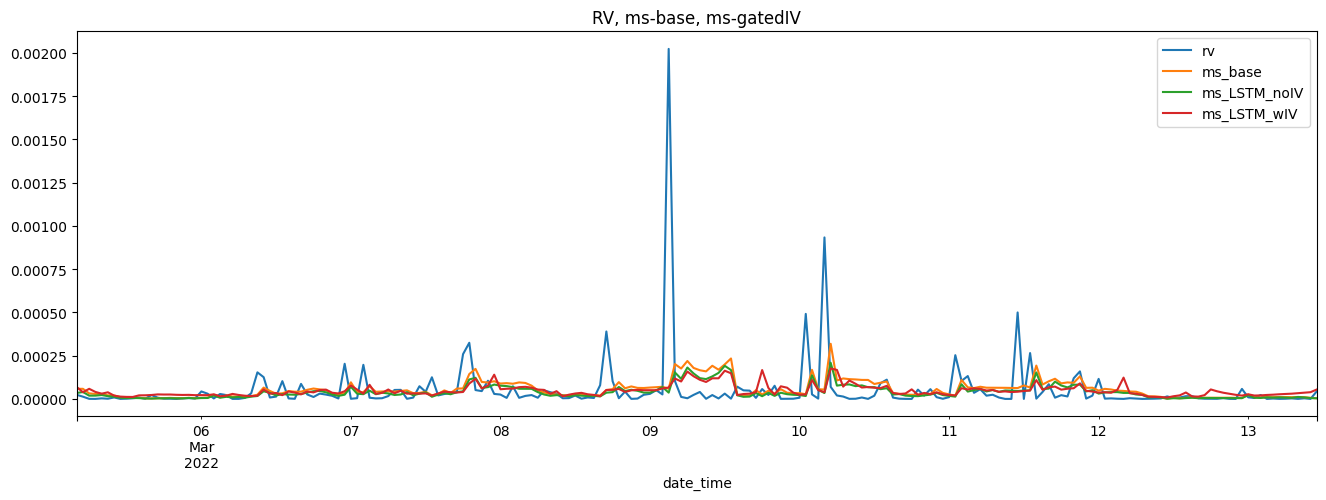

In [31]:
outputs_by_year[2022]['q1'][['rv', 'ms_base', 'ms_LSTM_noIV', 'ms_LSTM_wIV']][1500:1700].plot(figsize=(16,5), title = "RV, ms-base, ms-gatedIV")


### Evaluation

In [32]:
def metrics_new(y_true, y_pred, eps=1e-10):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)

    m = min(len(y_true), len(y_pred))
    y_true = np.clip(y_true[-m:], eps, None)
    y_pred = np.clip(y_pred[-m:], eps, None)

    # Errors
    err = y_true - y_pred

    # Core
    mse  = np.mean(err**2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(err))
    bias = np.mean(err)

    # Likelihood / variance metrics
    qlike = np.mean(np.log(y_pred) + y_true / y_pred)
    nll   = 0.5 * np.mean(np.log(2*np.pi) + np.log(y_pred) + y_true / y_pred)

    # Relative metrics
    hmse = np.mean((1 - y_true / y_pred)**2)
    hmae = np.mean(np.abs(1 - y_true / y_pred))

    # R2
    r2 = 1 - np.sum(err**2) / np.sum((y_true - np.mean(y_true))**2)

    # MADL (variance → signal)
    signal = y_pred - np.mean(y_pred)
    direction = np.sign(signal)
    madl = np.mean(-np.sign(y_true * direction) * np.abs(y_true))

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse,
        "NLL": nll,
        "QLIKE": qlike,
        "HMSE": hmse,
        "HMAE": hmae,
        "R2": r2,
        "Bias": bias,
        "MADL": madl
    }

In [33]:
outputs_by_year[2022]['q1'].columns

Index(['rv', 'ms_base', 'ms_LSTM_noIV', 'ms_LSTM_wIV', 'ar10', 'garch',
       'xg_boost', 'sv', 'gjr', 'egarch', 'tarch', 'midas', 'garch_m'],
      dtype='str')

In [34]:
from src.metrics import metrics
import numpy as np
import pandas as pd

quarters = [(y, q, Xq_by_year[y][q]) for y in sorted(Xq_by_year.keys()) for q in ["q1","q2","q3","q4"]]

tables_all = {}

for y, q, _ in quarters:
    results = {}

    rv2_q = np.asarray(rv2_gatedIV_by_year[y][q], float)

    # NEW: directly use dataframe columns
    df_q = outputs_by_year[y][q]

    ms_base_q      = df_q["ms_base"].to_numpy(float)
    ms_LSTM_noIV_q = df_q["ms_LSTM_noIV"].to_numpy(float)
    ms_LSTM_wIV_q  = df_q["ms_LSTM_wIV"].to_numpy(float)

    target_idx = df_q.index[-len(rv2_q):]

    garch_q    = df_q["garch"].reindex(target_idx).to_numpy(float)
    xgboost_q  = df_q["xg_boost"].reindex(target_idx).to_numpy(float)
    sv_q       = df_q["sv"].reindex(target_idx).to_numpy(float)
    gjr_q      = df_q["gjr"].reindex(target_idx).to_numpy(float)
    egarch_q   = df_q["egarch"].reindex(target_idx).to_numpy(float)
    tarch_q    = df_q["tarch"].reindex(target_idx).to_numpy(float)
    midas_q    = df_q["midas"].reindex(target_idx).to_numpy(float)
    garch_m_q  = df_q["garch_m"].reindex(target_idx).to_numpy(float)

    valid = (
        np.isfinite(rv2_q)
        & np.isfinite(ms_base_q)
        & np.isfinite(ms_LSTM_noIV_q)
        & np.isfinite(ms_LSTM_wIV_q)
        & np.isfinite(garch_q)
        & np.isfinite(xgboost_q)
        & np.isfinite(sv_q)
        & np.isfinite(gjr_q)
        & np.isfinite(egarch_q)
        & np.isfinite(tarch_q)
        & np.isfinite(midas_q)
        & np.isfinite(garch_m_q)
    )

    rv2_use         = rv2_q[valid]
    ms_base_use     = ms_base_q[valid]
    ms_LSTM_noIV_use= ms_LSTM_noIV_q[valid]
    ms_LSTM_wIV_use = ms_LSTM_wIV_q[valid]

    garch_use    = garch_q[valid]
    xgboost_use  = xgboost_q[valid]
    sv_use       = sv_q[valid]
    gjr_use      = gjr_q[valid]
    egarch_use   = egarch_q[valid]
    tarch_use    = tarch_q[valid]
    midas_use    = midas_q[valid]
    garch_m_use  = garch_m_q[valid]

    results["GARCH_M"]      = metrics_new(rv2_use, garch_m_use)
    results["MS_base"]      = metrics_new(rv2_use, ms_base_use)
    results["MS_LSTM_noIV"] = metrics_new(rv2_use, ms_LSTM_noIV_use)
    results["MS_LSTM_wIV"]  = metrics_new(rv2_use, ms_LSTM_wIV_use)
    results["GARCH"]        = metrics_new(rv2_use, garch_use)
    results["XGBoost"]      = metrics_new(rv2_use, xgboost_use)
    results["SV"]           = metrics_new(rv2_use, sv_use)
    results["GJR"]          = metrics_new(rv2_use, gjr_use)
    results["EGARCH"]       = metrics_new(rv2_use, egarch_use)
    results["TARCH"]        = metrics_new(rv2_use, tarch_use)
    results["MIDAS"]        = metrics_new(rv2_use, midas_use)

    metric_order = ["RMSE","MAE","MSE","NLL","QLIKE","HMSE","HMAE","R2","Bias","MADL"]
    table = pd.DataFrame(results).T[metric_order].round(6)

    if y not in tables_all:
        tables_all[y] = {}

    tables_all[y][q] = table

    print(f"{y}_{q}")
    print(table)

2022_q1
                   RMSE       MAE         MSE       NLL     QLIKE  \
GARCH_M        0.000153  0.000067    0.000000 -3.536544 -8.910965   
MS_base        0.000156  0.000067    0.000000 -3.388802 -8.615480   
MS_LSTM_noIV   0.000153  0.000058    0.000000 -3.193961 -8.225799   
MS_LSTM_wIV    0.000151  0.000062    0.000000 -3.510812 -8.859502   
GARCH          0.000167  0.000066    0.000000 -3.317008 -8.471893   
XGBoost        0.000153  0.000064    0.000000 -3.386071 -8.610019   
SV            17.499255  0.703879  306.223928 -1.443692 -4.725262   
GJR            0.000154  0.000065    0.000000 -3.383996 -8.605869   
EGARCH         0.000154  0.000065    0.000000 -3.383996 -8.605869   
TARCH          0.000154  0.000065    0.000000 -3.383996 -8.605869   
MIDAS          0.000155  0.000066    0.000000 -3.348547 -8.534971   

                     HMSE      HMAE            R2      Bias      MADL  
GARCH_M          9.319352  1.250955 -3.345900e-02 -0.000005  0.000008  
MS_base         30.

### Residual Diagnostics

In [81]:
import numpy as np
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import jarque_bera

def residual_diagnostics_2022_2023(outputs_by_year, Xq_by_year):
    years = [2022, 2023]
    quarters = ["q1", "q2", "q3", "q4"]
    out = []

    for y in years:
        for q in quarters:
            if y not in outputs_by_year or q not in outputs_by_year[y]:
                continue
            if y not in Xq_by_year or q not in Xq_by_year[y]:
                continue

            df_pred = outputs_by_year[y][q].copy()
            df_x = Xq_by_year[y][q].copy()

            if "rt" not in df_x.columns:
                continue

            r = df_x["rt"].astype(float)
            common_idx = df_pred.index.intersection(r.index)

            if len(common_idx) == 0:
                continue

            r_use = r.reindex(common_idx).to_numpy(float)

            for model in df_pred.columns:
                h_use = pd.to_numeric(df_pred[model].reindex(common_idx), errors="coerce").to_numpy(float)

                valid = np.isfinite(r_use) & np.isfinite(h_use) & (h_use > 0)
                if valid.sum() < 20:
                    continue

                z = r_use[valid] / np.sqrt(h_use[valid])

                try:
                    lb_p = acorr_ljungbox(z, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
                except:
                    lb_p = np.nan

                try:
                    arch_p = het_arch(z, nlags=10)[1]
                except:
                    arch_p = np.nan

                try:
                    jb_p = jarque_bera(z)[1]
                except:
                    jb_p = np.nan

                out.append({
                    "Year": y,
                    "Quarter": q,
                    "Model": model,
                    "N": int(valid.sum()),
                    "LB_pvalue": lb_p,
                    "ARCH_pvalue": arch_p,
                    "JB_pvalue": jb_p
                })

    return pd.DataFrame(out).sort_values(["Year", "Quarter", "Model"]).reset_index(drop=True)


diag_table = residual_diagnostics_2022_2023(outputs_by_year, Xq_by_year)
print(diag_table)

     Year Quarter     Model     N  LB_pvalue  ARCH_pvalue     JB_pvalue
0    2022      q1      ar10  1090   0.987731     1.000000  0.000000e+00
1    2022      q1    egarch  2144   0.846513     0.028017  0.000000e+00
2    2022      q1     garch  2144   0.852884     0.177523  0.000000e+00
3    2022      q1   garch_m  2144   0.908862     0.819199  0.000000e+00
4    2022      q1       gjr  2144   0.846513     0.028017  0.000000e+00
..    ...     ...       ...   ...        ...          ...           ...
99   2023      q4   ms_base  2192   0.926842     0.880571  0.000000e+00
100  2023      q4        rv  2184   0.004716     1.000000  9.075877e-80
101  2023      q4        sv  2192   0.999826     1.000000  0.000000e+00
102  2023      q4     tarch  2192   0.908465     0.691104  0.000000e+00
103  2023      q4  xg_boost  2192   0.899404     0.697762  0.000000e+00

[104 rows x 7 columns]


In [82]:
summary_table = (
    diag_table.groupby("Model")[["LB_pvalue", "ARCH_pvalue", "JB_pvalue"]]
    .mean()
    .sort_index()
)

print(summary_table)

              LB_pvalue  ARCH_pvalue     JB_pvalue
Model                                             
ar10           0.831815     0.873181  0.000000e+00
egarch         0.721695     0.623995  0.000000e+00
garch          0.756204     0.746663  0.000000e+00
garch_m        0.557011     0.770991  0.000000e+00
gjr            0.721695     0.623995  0.000000e+00
midas          0.705524     0.569782  0.000000e+00
ms_LSTM_noIV   0.867815     0.711973  0.000000e+00
ms_LSTM_wIV    0.697664     0.718593  0.000000e+00
ms_base        0.871515     0.721902  0.000000e+00
rv             0.002442     1.000000  1.006240e-78
sv             0.910228     0.949771  0.000000e+00
tarch          0.721695     0.623995  0.000000e+00
xg_boost       0.725822     0.623795  0.000000e+00


In [83]:

outputs_by_year[2022]['q1'].columns

Index(['rv', 'ms_base', 'ms_LSTM_noIV', 'ms_LSTM_wIV', 'ar10', 'garch',
       'xg_boost', 'sv', 'gjr', 'egarch', 'tarch', 'midas', 'garch_m'],
      dtype='str')

<Axes: xlabel='date_time'>

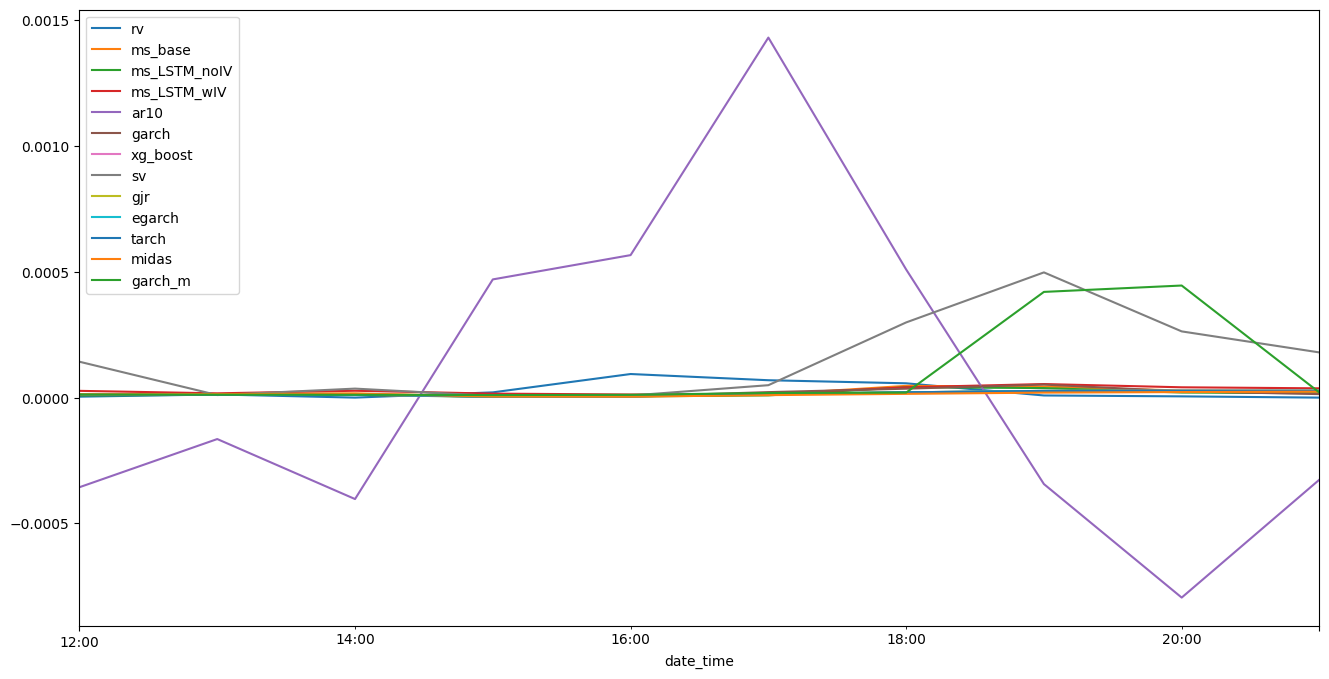

In [84]:

outputs_by_year[2022]['q1'][['rv', 'ms_base', 'ms_LSTM_noIV', 'ms_LSTM_wIV', 'ar10', 'garch',
       'xg_boost', 'sv', 'gjr', 'egarch', 'tarch', 'midas', 'garch_m']].iloc[20:30].plot(figsize = (16, 8))

### Prepare signals from the model 

In [35]:
def prepare_signals(Xq_by_year, outputs_by_year):
# this function builds a nested dictionary by year and quarter where each value is one DataFrame
    YEARS = [2022, 2023, 2024, 2025]
    quarters = ["q1", "q2", "q3", "q4"]
    # so our signal should have an up or down 
    
    out = {
        y: {
            q : pd.concat ( [Xq_by_year[y][q]["rt"], outputs_by_year[y][q]], axis = 1)
            for q in quarters
        }
        for y in YEARS
        }
    return out 
out = prepare_signals(Xq_by_year, outputs_by_year)



In [36]:
out[2022]['q1']

,rt,rv,ms_base,ms_LSTM_noIV,ms_LSTM_wIV,ar10,garch,xg_boost,sv,gjr,egarch,tarch,midas,garch_m
date_time,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,0.009782,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 01:00:00+00:00,0.002855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 02:00:00+00:00,0.000406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 03:00:00+00:00,0.000085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 04:00:00+00:00,-0.002030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-31 19:00:00+00:00,-0.007949,6.318568e-05,0.000044,0.000036,0.000039,-0.002807,0.000060,0.000052,0.000053,0.000052,0.000052,0.000052,0.000044,0.000059
2022-03-31 20:00:00+00:00,0.003567,1.272611e-05,0.000050,0.000032,0.000034,-0.003722,0.000054,0.000058,0.000218,0.000058,0.000058,0.000058,0.000052,0.000060
2022-03-31 21:00:00+00:00,0.000371,1.378822e-07,0.000048,0.000040,0.000063,-0.003296,0.000052,0.000059,0.000064,0.000059,0.000059,0.000059,0.000058,0.000052


### Logic and create out_full

In [37]:
out_full = pd.concat([out[y][q] for y in sorted(out) for q in ["q1","q2","q3","q4"]]).sort_index()

### Market 01

In [38]:
### New Market tesing

import pandas as pd
import numpy as np
from scipy.stats import norm


class Chain:
    def __init__(self):
        self.instruments = []

class Instrument:
    def __init__(self, symbol, strike, right, direction, price_per_contract, expiry ):
        self.Symbol = symbol
        self.Strike = strike
        self.Right = right
        self.Direction = direction
        self.Price = price_per_contract
        self.Expiry = expiry
class Holdings: 
    def __init__(self, cash, now):
        self.time = now
        self.instruments = [] # it has direction and all option contracts held at the moment
        self.cash = cash
        
    def get_cash(self):
        return self.cash

    def get_time(self):
        return self.time
        
    #later define your key as {strike, maturity, now}
    def long_instrument(self, instrument):
        self.instruments.append(instrument)

    def short_instrument(self, instrument):
        self.instruments.append(instrument)
    # later define key as key = (strike, expiry, Right,  direction)

    def close_position(self, key):
        strike, expiry, right,  direction = key
        self.instruments = [
            i for i in self.instruments
            if not (i.Strike == strike and i.Expiry == expiry and i.Right == right and i.Direction == direction)
        ]

class Market:
    def __init__(self, option_df, time_df, starting_cash=100000):
        self.time = time_df.index
        self.option = option_df.copy()
        self.chain = Chain()
        self.option_values = []
        self.time_df = time_df.copy()
        self.spot = None
        self.option["strike"] = self.option["instrument_name"].str.split("-").str[2].astype(float)
        self.option["type"] = self.option["instrument_name"].str.split("-").str[3]
        # self.option["maturity"] = pd.to_datetime(
        #     self.option["instrument_name"].str.split("-").str[1], format="%d%b%y"
        # ).dt.floor("D")
        self.option["maturity"] = pd.to_datetime(
            self.option["instrument_name"].str.split("-").str[1], format="%d%b%y").dt.tz_localize("UTC").dt.floor("h")
        self.option["price_per_contract"] = self.option["price"] * self.option["index_price"]

        self.option["date_time"] = pd.to_datetime(self.option["date_time"]).dt.tz_localize("UTC").dt.floor("h")
    
        self.orders = []
        self.starting_cash = starting_cash
        self.cash = starting_cash
        self.equity_history = []

        self.now = None
        self.holdings = Holdings(starting_cash, self.now)   
        self.current = pd.DataFrame()

    def update(self, now):
        self.now = pd.Timestamp(now).floor("h")
        # self.now = pd.Timestamp(now).tz_localize("UTC").floor("h")
        self.holdings.time = self.now
        self.current = self.option[self.option["date_time"] == self.now].copy()
        self.spot = self.time_df.loc[self.now, "close"]
        self.chain.instruments = [
            Instrument(
                row["instrument_name"],
                row["strike"],
                row["type"],
                row["direction"],
                row["price_per_contract"],
                row["maturity"]
            )
            for _, row in self.current.iterrows()
        ]
        self.remove_expired() # remove epired options, avoid a false flag
    
    def remove_expired(self):
        self.holdings.instruments = [i for i in self.holdings.instruments if i.Expiry > self.now]

    def get_equity_history(self):
        if not self.equity_history:
            return pd.DataFrame(columns=["option_value", "cash", "equity"])
        return pd.DataFrame(self.equity_history).set_index("time")

    # def record_equity(self):
    #     option_value = self.option_value() if self.option_value() != 0.0 else sum(i.Price for i in self.holdings.instruments)
    #     self.option_values.append(option_value)

    #     self.equity_history.append({
    #         "time": self.now,
    #         "option_value": option_value,
    #         "cash": self.cash,
    #         "equity": self.cash + option_value
    #     })

    def record_equity(self):
        option_value = self.option_value()
        self.option_values.append(option_value)

        self.equity_history.append({
            "time": self.now,
            "option_value": option_value,
            "cash": self.cash,
            "equity": self.cash + option_value
        })
        
    def buy(self, instrument, qty=1):
        order = {
            "time": self.now,
            "symbol": instrument.Symbol,
            "strike": instrument.Strike,
            "expiry": instrument.Expiry,
            "right": instrument.Right,
            "spot_entry": self.spot,
            "side": "long",
            "qty": qty,
            "entry_price": instrument.Price
        }

        self.orders.append(order)
        self.cash -= instrument.Price * qty * 100.0

        for _ in range(qty):
            self.holdings.instruments.append(
                Instrument(
                    instrument.Symbol,
                    instrument.Strike,
                    instrument.Right,
                    instrument.Direction,
                    instrument.Price,
                    instrument.Expiry
                )
            )
        # if instrument.Direction == "buy" :
        #     self.holdings.long_instrument(instrument)
        return order

    def sell(self, instrument, qty=1):
        order = {
            "time": self.now,
            "symbol": instrument.Symbol,
            "strike": instrument.Strike,
            "expiry": instrument.Expiry,
            "right": instrument.Right,
            "spot_entry": self.spot,
            "side": "short",
            "qty": qty,
            "entry_price": instrument.Price
        }

        self.orders.append(order)
        self.cash += instrument.Price * qty * 100.0

        for _ in range(qty):
            self.holdings.instruments.append(
                Instrument(
                    instrument.Symbol,
                    instrument.Strike,
                    instrument.Right,
                    instrument.Direction,
                    instrument.Price,
                    instrument.Expiry
                )
            )

        # if instrument.Direction == "sell" :
        #     self.holdings.short_instrument(instrument)
        return order

    def get_order(self):
        return self.order
    
    def in_position(self):
        return len(self.holdings.instruments) > 0   
        

    def close_price(self, n=60):
        return self.time_df["close"].loc[:self.now].tail(n)

    def variance(self, n=60):
        close = self.close_price(n)
        ret = np.log(close / close.shift(1)).dropna()
        if len(ret) == 0:
            return np.nan
        return ret.var() * (252 * 6.5)


    def std(self, n=60):
        close = self.close_price(n)
        ret = np.log(close / close.shift(1)).dropna()
        if len(ret) == 0:
            return np.nan
        return ret.std()

    def option_value(self):
        option_value = 0.0

        if self.now is None or not self.holdings.instruments:
            return 0.0

        spot = self.close_price(n=1).iloc[-1]
        var = self.variance(n=60)
        r = 0.01

        if pd.isna(var) or var <= 0 or pd.isna(spot):
            return 0.0

        for instrument in self.holdings.instruments:
            strike = instrument.Strike
            tau = (instrument.Expiry - self.now) / pd.Timedelta(days=365)

            if tau <= 0:
                if instrument.Right == "C":
                    price_now = max(spot - strike, 0.0)
                else:
                    price_now = max(strike - spot, 0.0)
            else:
                den = np.sqrt(var) * np.sqrt(tau)
                if den <= 0:
                    price_now = 0.0
                else:
                    d1 = (np.log(spot / strike) + (r + var / 2) * tau) / den
                    d2 = d1 - den
                    Nd1 = norm.cdf(d1)
                    Nd2 = norm.cdf(d2)
                    Nd1_put = norm.cdf(-d1)
                    Nd2_put = norm.cdf(-d2)

                    if instrument.Right == "C":
                        price_now = spot * Nd1 - strike * np.exp(-r * tau) * Nd2
                    else:
                        price_now = strike * np.exp(-r * tau) * Nd2_put - spot * Nd1_put

            # instrument.current_option_price = price_now

            if instrument.Direction == "sell":
                option_value += price_now * 100.0
            else:
                option_value -= price_now * 100.0 

        return option_value

    # def pricer(self, key):
    #     option_value = 0.0
    #     strike, expiry, right, direction = key
    #     if self.now is None or not self.holdings.instruments:
    #         return 0.0

    #     spot = self.close_price(n=1).iloc[-1]
    #     var = self.variance(n=60)
    #     r = 0.01

    #     if pd.isna(var) or var <= 0 or pd.isna(spot):
    #         return 0.0
    #     instrument = [i for i in self.holdings.instruments if i.Strike == strike and i.Expiry == expiry and i.Right == right and i.Direction == direction]
    #     strike = instrument.Strike
    #     tau = (instrument.Expiry - self.now) / pd.Timedelta(days=365)

    #     if tau <= 0:
    #         if instrument.Right == "C":
    #             price_now = max(spot - strike, 0.0)
    #         else:
    #             price_now = max(strike - spot, 0.0)
    #     else:
    #         den = np.sqrt(var) * np.sqrt(tau)
    #         if den <= 0:
    #             price_now = 0.0
    #         else:
    #             d1 = (np.log(spot / strike) + (r + var / 2) * tau) / den
    #             d2 = d1 - den
    #             Nd1 = norm.cdf(d1)
    #             Nd2 = norm.cdf(d2)
    #             Nd1_put = norm.cdf(-d1)
    #             Nd2_put = norm.cdf(-d2)

    #             if instrument.Right == "C":
    #                 price_now = spot * Nd1 - strike * np.exp(-r * tau) * Nd2
    #             else:
    #                 price_now = strike * np.exp(-r * tau) * Nd2_put - spot * Nd1_put

    #     # instrument.current_option_price = price_now

    #     if instrument.Direction == "sell":
    #         option_value += price_now * 100.0
    #     else:
    #         option_value -= price_now * 100.0 

    #     return option_value

    def pricer(self, key):
        strike, expiry, right, direction = key

        if self.now is None:
            return 0.0

        spot = self.close_price(n=1).iloc[-1]
        var = self.variance(n=60)
        r = 0.01

        if pd.isna(var) or var <= 0 or pd.isna(spot):
            return 0.0

        instrument = next(
            (i for i in self.holdings.instruments
            if i.Strike == strike and i.Expiry == expiry and i.Right == right and i.Direction == direction),
            None
        )

        if instrument is None:
            return 0.0

        tau = (instrument.Expiry - self.now) / pd.Timedelta(days=365)

        if tau <= 0:
            if instrument.Right == "C":
                price_now = max(spot - strike, 0.0)
            else:
                price_now = max(strike - spot, 0.0)
        else:
            den = np.sqrt(var) * np.sqrt(tau)
            if den <= 0:
                price_now = 0.0
            else:
                d1 = (np.log(spot / strike) + (r + var / 2) * tau) / den
                d2 = d1 - den
                Nd1 = norm.cdf(d1)
                Nd2 = norm.cdf(d2)
                Nd1_put = norm.cdf(-d1)
                Nd2_put = norm.cdf(-d2)

                if instrument.Right == "C":
                    price_now = spot * Nd1 - strike * np.exp(-r * tau) * Nd2
                else:
                    price_now = strike * np.exp(-r * tau) * Nd2_put - spot * Nd1_put

        if instrument.Direction == "sell":
            return -price_now * 100.0
        else:
            return price_now * 100.0
        
        
    
    # def liquidate(self, key, instrument):  # this has to be an instrument from holdings chain
    #     print(f"Liquidate this option: {key}")
    #     strike, expiry, right, direction = key 

    #     if instrument.Direction == "buy": 
    #         instrument_to_sell = next(
    #             (i for i in self.chain.instruments
    #             if i.Strike == strike and i.Expiry == expiry and i.Right == right and i.Direction == "sell"),
    #             None
    #         )
    #         if instrument_to_sell is not None:
    #             # self.sell(instrument_to_sell, qty=1)
    #             # 
    #             self.holdings.close_position((strike, expiry, right, direction))

    #     if instrument.Direction == "sell":
    #         instrument_to_buy = next(
    #             (i for i in self.chain.instruments
    #             if i.Strike == strike and i.Expiry == expiry and i.Right == right and i.Direction == "buy"),
    #             None
    #         )
    #         if instrument_to_buy is not None:
    #             self.buy(instrument_to_buy, qty=1)
    #             self.holdings.close_position((strike, expiry, right, direction))

    #     return

    def liquidate(self, key, instrument):
        print(f"Liquidate this option: {key}")
        strike, expiry, right, direction = key

        if instrument.Direction == "buy":
            instrument_to_sell = next(
                (i for i in self.chain.instruments
                if i.Strike == strike and i.Expiry == expiry and i.Right == right and i.Direction == "sell"),
                None
            )
            if instrument_to_sell is not None:
                self.cash += instrument_to_sell.Price * 100.0
                self.holdings.close_position((strike, expiry, right, direction))

        if instrument.Direction == "sell":
            instrument_to_buy = next(
                (i for i in self.chain.instruments
                if i.Strike == strike and i.Expiry == expiry and i.Right == right and i.Direction == "buy"),
                None
            )
            if instrument_to_buy is not None:
                self.cash -= instrument_to_buy.Price * 100.0
                self.holdings.close_position((strike, expiry, right, direction))

        return

    def option_value(self):
        option_value = 0.0

        if self.now is None or not self.holdings.instruments:
            return 0.0

        spot = self.close_price(n=1).iloc[-1]
        var = self.variance(n=60)
        r = 0.01

        if pd.isna(var) or var <= 0 or pd.isna(spot):
            return 0.0

        for instrument in self.holdings.instruments:
            strike = instrument.Strike
            tau = (instrument.Expiry - self.now) / pd.Timedelta(days=365)

            if tau <= 0:
                if instrument.Right == "C":
                    price_now = max(spot - strike, 0.0)
                else:
                    price_now = max(strike - spot, 0.0)
            else:
                den = np.sqrt(var) * np.sqrt(tau)
                if den <= 0:
                    price_now = 0.0
                else:
                    d1 = (np.log(spot / strike) + (r + var / 2) * tau) / den
                    d2 = d1 - den
                    Nd1 = norm.cdf(d1)
                    Nd2 = norm.cdf(d2)
                    Nd1_put = norm.cdf(-d1)
                    Nd2_put = norm.cdf(-d2)

                    if instrument.Right == "C":
                        price_now = spot * Nd1 - strike * np.exp(-r * tau) * Nd2
                    else:
                        price_now = strike * np.exp(-r * tau) * Nd2_put - spot * Nd1_put

            if instrument.Direction == "sell":
                option_value -= price_now * 100.0
            else:
                option_value += price_now * 100.0

        return option_value

### Market class end

In [89]:
market = Market(df, d_btc, starting_cash = 1000000)


In [90]:

QUARTERS = ['q1', 'q2', 'q3', 'q4']
YEARS = [2022, 2023, 2024, 2025]

### Strategy 1

* Signal uses forecast vs realized volatility with **60-point history** and a **3-point rolling mean**.
* **Long Straddle**: top 20% signal at 15:00–16:00, buy ATM call + put (1–3 day expiry).
* **Short Strangle**: bottom 20% signal at 11:00–15:00, sell OTM call + put (~3-day expiry).
* Exit after **1 day**, on forecast extremes, after 15:00 next day, or near expiry.
* One 2-leg trade at a time, max one entry per day.


### Function : execute trading strategy (edited)

In [39]:
def execute_trading_strategy(bt_year, bt_quarter, model, outputs_by_year, market,
                             lookback_hours=60, mean_hours=3, hold_days=1, expiry_days = 3):
    out_full = outputs_by_year[bt_year][bt_quarter].copy()
    now_list = out_full.index

    signal = (out_full[model] - out_full["rv"]) / out_full["rv"]

    entered_day = None
    position_side = None
    entry_time = None

    for now in now_list:
        market.update(now)

        hist_signal = signal.loc[:now].dropna()
        hist_forecast = out_full.loc[:now, "ms_LSTM_wIV"].dropna()

        if len(hist_signal) < lookback_hours or len(hist_forecast) < lookback_hours:
            market.record_equity()
            continue

        signal_window = hist_signal.iloc[-lookback_hours:]
        forecast_window = hist_forecast.iloc[-lookback_hours:]

        s_now = hist_signal.iloc[-1]
        q_hi = signal_window.quantile(0.80)
        q_lo = signal_window.quantile(0.20)
        forecast_mean_window = forecast_window.rolling(mean_hours).mean().dropna()
        
        if forecast_mean_window.empty:
            market.record_equity()
            continue

        forecast_mean_now = hist_forecast.iloc[-mean_hours:].mean()
        forecast_top10 = forecast_mean_window.quantile(0.90)
        forecast_bot10 = forecast_mean_window.quantile(0.10)

        hour = now.hour
        holdings_count = len(market.holdings.instruments)

        if holdings_count == 2:
            should_exit = False

            if hold_days is not None and entry_time is not None and now >= entry_time + pd.Timedelta(days=hold_days):
                should_exit = True

            if entered_day is not None and now.date() > entered_day:
                if position_side == "long_straddle" and forecast_mean_now >= forecast_top10:
                    should_exit = True
                elif position_side == "short_strangle" and forecast_mean_now <= forecast_bot10:
                    should_exit = True
                # NEW REMOVE (1line)

            if any(i.Expiry - now <= pd.Timedelta(hours=12) for i in market.holdings.instruments):
                should_exit = True

            if should_exit:
                for i in list(market.holdings.instruments):
                    key = (i.Strike, i.Expiry, i.Right, i.Direction)
                    market.liquidate(key, i)

                position_side = None
                entry_time = None

            market.record_equity()
            continue

        if holdings_count == 1:
            for i in list(market.holdings.instruments):
                key = (i.Strike, i.Expiry, i.Right, i.Direction)
                market.liquidate(key, i)

            position_side = None
            entry_time = None
            market.record_equity()
            continue

        if entered_day is not None and entered_day == now.date():
            market.record_equity()
            continue

        last_five = market.close_price(n=5)
        if last_five.empty:
            market.record_equity()
            continue

        last = last_five.iloc[-1]

        if s_now >= q_hi and 15 <= hour < 16:
            calls = [i for i in market.chain.instruments if i.Right == "C" and i.Direction == "buy"]
            puts = [i for i in market.chain.instruments if i.Right == "P" and i.Direction == "buy"]

            valid_calls = [i for i in calls if pd.Timedelta(days=1) <= i.Expiry - now <= pd.Timedelta(days=3)]
            valid_puts = [i for i in puts if pd.Timedelta(days=1) <= i.Expiry - now <= pd.Timedelta(days=3)]

            if not valid_calls or not valid_puts:
                market.record_equity()
                continue

            common_expiries = sorted(set(i.Expiry for i in valid_calls) & set(i.Expiry for i in valid_puts))
            if not common_expiries:
                market.record_equity()
                continue

            expiry = common_expiries[0]

            expiry_calls = [i for i in valid_calls if i.Expiry == expiry]
            expiry_puts = [i for i in valid_puts if i.Expiry == expiry]

            common_strikes = sorted(set(i.Strike for i in expiry_calls) & set(i.Strike for i in expiry_puts))
            if not common_strikes:
                market.record_equity()
                continue

            atm_strike = min(common_strikes, key=lambda k: abs(k - last))

            long_call = next((i for i in expiry_calls if i.Strike == atm_strike), None)
            long_put = next((i for i in expiry_puts if i.Strike == atm_strike), None)

            if long_call is None or long_put is None:
                market.record_equity()
                continue

            before_count = len(market.holdings.instruments)

            market.buy(long_call, qty=1)
            market.buy(long_put, qty=1)

            after_count = len(market.holdings.instruments)

            if after_count - before_count == 2:
                entered_day = now.date()
                position_side = "long_straddle"
                entry_time = now
            else:
                for i in list(market.holdings.instruments):
                    key = (i.Strike, i.Expiry, i.Right, i.Direction)
                    market.liquidate(key, i)
                position_side = None
                entry_time = None

        elif s_now <= q_lo and 11 <= hour < 15:
            calls = [i for i in market.chain.instruments if i.Right == "C" and i.Direction == "sell" and i.Strike > last]
            puts = [i for i in market.chain.instruments if i.Right == "P" and i.Direction == "sell" and i.Strike < last]

            valid_calls = [i for i in calls if pd.Timedelta(days=1) <= i.Expiry - now <= pd.Timedelta(days=3)]
            valid_puts = [i for i in puts if pd.Timedelta(days=1) <= i.Expiry - now <= pd.Timedelta(days=3)]

            if not valid_calls or not valid_puts:
                market.record_equity()
                continue

            common_expiries = sorted(set(i.Expiry for i in valid_calls) & set(i.Expiry for i in valid_puts))
            if not common_expiries:
                market.record_equity()
                continue

            # expiry = common_expiries[0]
            expiry = min(common_expiries, key=lambda e: abs((e - now) - pd.Timedelta(days=expiry_days)))

            expiry_calls = [i for i in valid_calls if i.Expiry == expiry]
            expiry_puts = [i for i in valid_puts if i.Expiry == expiry]

            short_call = min(expiry_calls, key=lambda i: abs(i.Strike - 1.02 * last), default=None)
            short_put = min(expiry_puts, key=lambda i: abs(i.Strike - 0.98 * last), default=None)

            if short_call is None or short_put is None:
                market.record_equity()
                continue

            before_count = len(market.holdings.instruments)

            market.sell(short_call, qty=1)
            market.sell(short_put, qty=1)

            after_count = len(market.holdings.instruments)

            if after_count - before_count == 2:
                entered_day = now.date()
                position_side = "short_strangle"
                entry_time = now
            else:
                for i in list(market.holdings.instruments):
                    key = (i.Strike, i.Expiry, i.Right, i.Direction)
                    market.liquidate(key, i)
                position_side = None
                entry_time = None

        market.record_equity()


### Default testing done on 01_03
Below is done on 07_30. Since longer horizons are better suited according to regressions.

### Testing Strategy 07_30 (2022)

In [40]:
# Hourly data
d_btc = pd.read_parquet("../data/rawData/btc_underlying_minutely_2022.parquet")
d_btc.set_index(pd.to_datetime(d_btc["date_time"]), inplace = True)

df = pd.read_parquet("../data/rawData/derivative_data_2022.parquet")

In [41]:
market = Market(df,d_btc, starting_cash = 1000000)

In [42]:
from tqdm.auto import tqdm

# List of models to backtest
models_to_test = [
    "ms_LSTM_wIV", "ms_LSTM_noIV", "ms_base", "garch",
    "xg_boost", "tarch", "midas", "sv", "gjr", "egarch",
    "ar10", "garch_m"
]

strategy_results = {}

# Hardcoded for 2022 only
target_years = [2022]
total_runs = len(target_years) * 4 * len(models_to_test)
pbar = tqdm(total=total_runs, desc="Backtesting 2022")

for y in target_years:
    if y not in outputs_by_year:
        print(f"Year {y} not found in outputs_by_year.")
        pbar.update(4 * len(models_to_test))
        continue
        
    for q in ["q1", "q2", "q3", "q4"]:
        if q not in outputs_by_year[y] or outputs_by_year[y][q] is None:
            pbar.update(len(models_to_test))
            continue
            
        for model_name in models_to_test:
            pbar.set_description(f"Processing {y} {q} | {model_name}")
            
            if model_name not in outputs_by_year[y][q].columns:
                pbar.update(1)
                continue
            
            # Resetting market for each specific model run
            market = Market(df, d_btc, starting_cash=1000000)

            try:
                execute_trading_strategy(
                    bt_year=y, 
                    bt_quarter=q, 
                    model=model_name, 
                    outputs_by_year=outputs_by_year, 
                    market=market,
                    expiry_days = 30,
                    hold_days = 7, 
                )

                history_key = f"{model_name}_{str(y)[2:]}_{q}"
                equity_curve = market.get_equity_history()
                
                strategy_results[history_key] = equity_curve
                globals()[history_key] = equity_curve
                
            except Exception as e:
                print(f"\nError on {y} {q} model {model_name}: {e}")
            
            pbar.update(1)

pbar.close()
speak_done()
print("\nExecution Finished for 2022.")

c:\Users\HP\Documents\CODE_BOOK_4\THESIS_WORKING\THESIS_2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing 2022 q1 | ms_LSTM_wIV:   0%|          | 0/48 [00:00<?, ?it/s]

Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (45000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (45000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-0

Processing 2022 q1 | ms_LSTM_noIV:   2%|▏         | 1/48 [03:48<2:59:00, 228.53s/it]

Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (45000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (45000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (48000.0, Timestamp('2022-0

Processing 2022 q1 | ms_base:   4%|▍         | 2/48 [07:21<2:47:57, 219.08s/it]     

...

Liquidate this option: (16000.0, Timestamp('2023-01-01 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (20000.0, Timestamp('2022-10-06 00:00:00+0000', tz='UTC'), 'C', 'buy')
Liquidate this option: (20000.0, Timestamp('2022-10-06 00:00:00+0000', tz='UTC'), 'P', 'buy')
Liquidate this option: (20500.0, Timestamp('2022-10-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (19500.0, Timestamp('2022-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (20500.0, Timestamp('2022-10-08 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (20000.0, Timestamp('2022-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (20000.0, Timestamp('2022-10-09 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (19000.0, Timestamp('2022-10-09 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (20000.0, Timestamp('2022-10-09 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (19000.0, Timestamp('2022-10-

Processing 2022 q4 | garch_m:  98%|█████████▊| 47/48 [2:56:36<03:44, 224.70s/it]

Liquidate this option: (20000.0, Timestamp('2022-10-06 00:00:00+0000', tz='UTC'), 'C', 'buy')
Liquidate this option: (20000.0, Timestamp('2022-10-06 00:00:00+0000', tz='UTC'), 'P', 'buy')
Liquidate this option: (20500.0, Timestamp('2022-10-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (19500.0, Timestamp('2022-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (20500.0, Timestamp('2022-10-09 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (19500.0, Timestamp('2022-10-09 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (19500.0, Timestamp('2022-10-09 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (19500.0, Timestamp('2022-10-10 00:00:00+0000', tz='UTC'), 'C', 'buy')
Liquidate this option: (19500.0, Timestamp('2022-10-10 00:00:00+0000', tz='UTC'), 'P', 'buy')
Liquidate this option: (20000.0, Timestamp('2022-10-12 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (19000.0, Timestamp('2022-10-12

Processing 2022 q4 | garch_m: 100%|██████████| 48/48 [3:00:20<00:00, 225.42s/it]



Execution Finished for 2022.


### Equity Line 07_30 (2022)

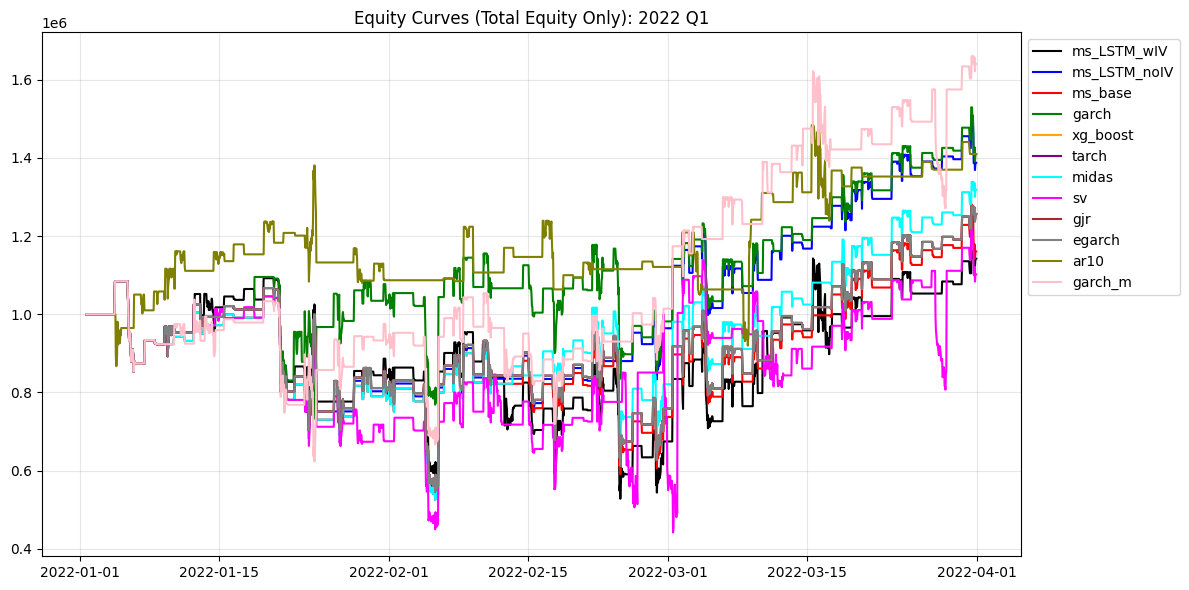

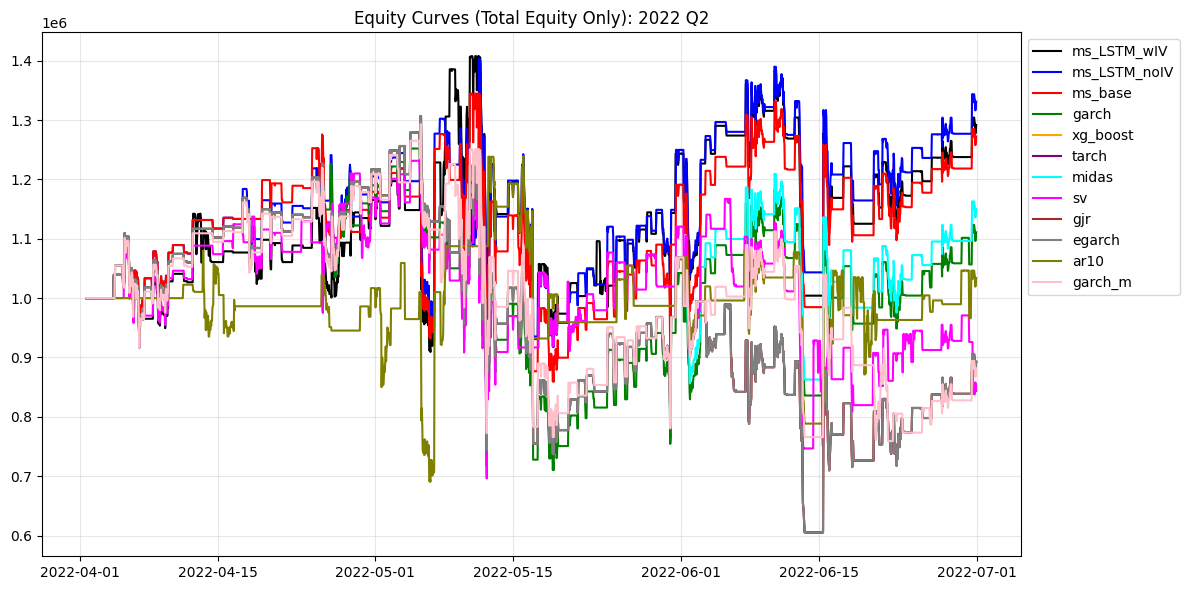

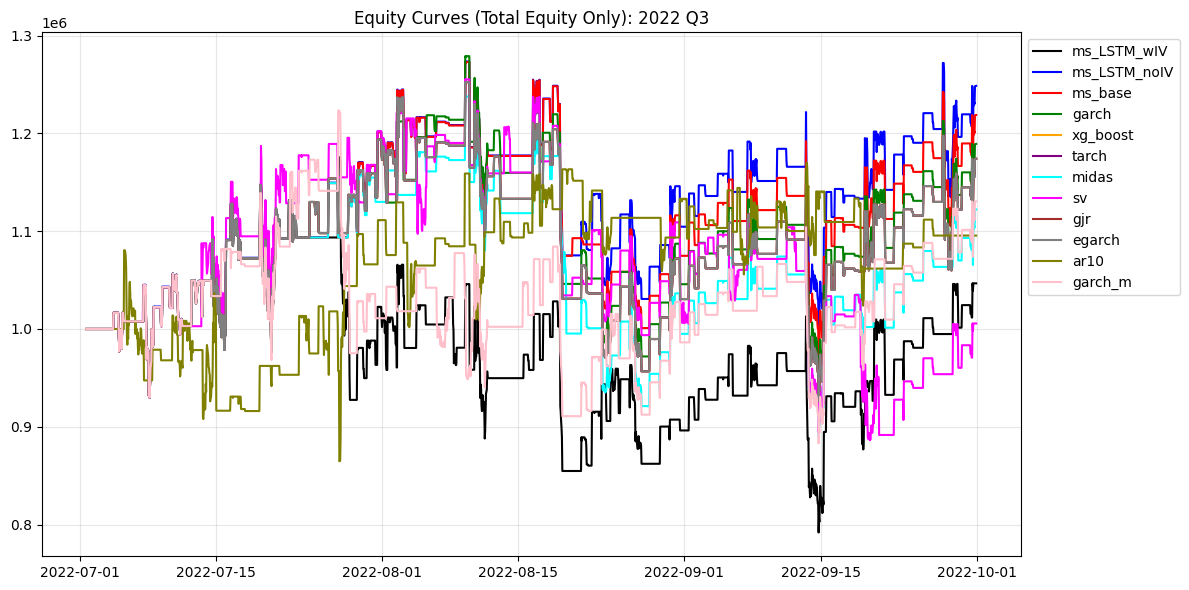

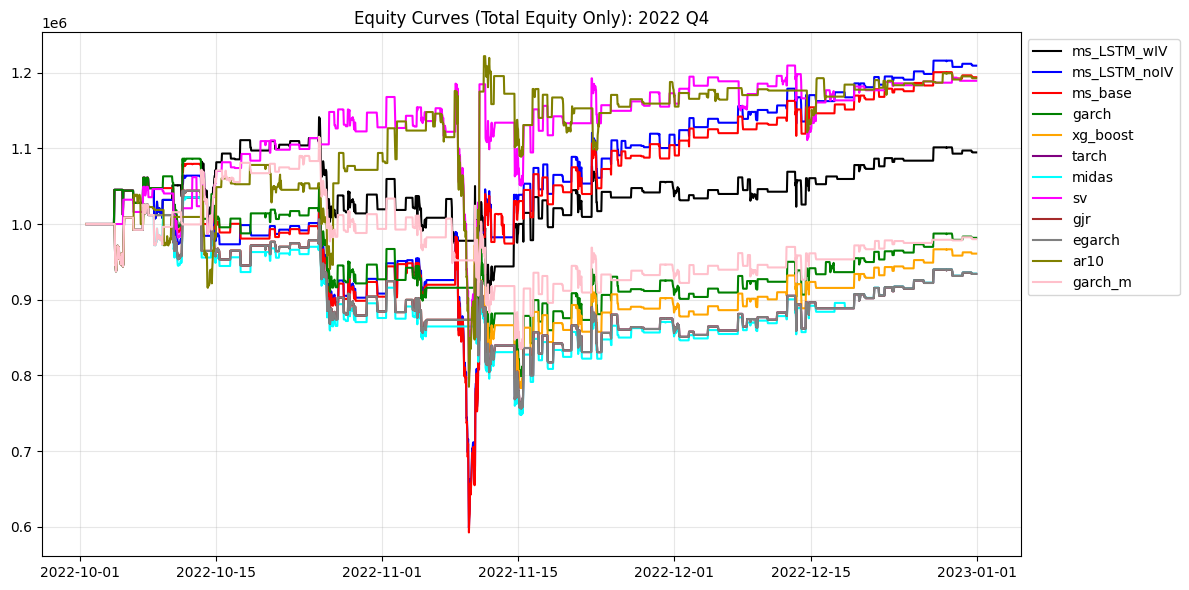

In [43]:
import matplotlib.pyplot as plt

# Define colors for consistency
colors = {
    "ms_LSTM_wIV": "black", "ms_LSTM_noIV": "blue", "ms_base": "red",
    "garch": "green", "xg_boost": "orange", "tarch": "purple",
    "midas": "cyan", "sv": "magenta", "gjr": "brown", "egarch": "gray",
    "ar10": "olive", "garch_m": "pink"
}

for y in [2022]: 
    for q in ["q1", "q2", "q3", "q4"]:
        if y not in outputs_by_year or q not in outputs_by_year[y]:
            continue
            
        plt.figure(figsize=(12, 6))
        plot_exists = False
        
        for model_name in models_to_test:
            var_name = f"{model_name}_{str(y)[2:]}_{q}"
            
            if var_name in globals():
                data = globals()[var_name]
                
                # Extract only the equity col
                try:
                    # If it's a DataFrame
                    equity_curve = data['equity']
                except (TypeError, KeyError, IndexError):
                    # Fallback if it's a list ortuple of (equity, cash, options)
                    equity_curve = [x[0] for x in data] if isinstance(data[0], (list, tuple)) else data
                
                if len(equity_curve) > 0:
                    plt.plot(equity_curve, label=model_name, color=colors.get(model_name))
                    plot_exists = True
        
        if plot_exists:
            plt.title(f"Equity Curves (Total Equity Only): {y} {q.upper()}")
            plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            plt.close()

### save

In [ ]:
# Save backtest results.
import pickle

data_to_dump = {
    # Q1 2022
    "ms_LSTM_wIV_22_q1": ms_LSTM_wIV_22_q1, "ms_LSTM_noIV_22_q1": ms_LSTM_noIV_22_q1,
    "ms_base_22_q1": ms_base_22_q1, "garch_22_q1": garch_22_q1,
    "xg_boost_22_q1": xg_boost_22_q1, "tarch_22_q1": tarch_22_q1,
    "midas_22_q1": midas_22_q1, "sv_22_q1": sv_22_q1,
    "gjr_22_q1": gjr_22_q1, "egarch_22_q1": egarch_22_q1,

    # Q2 2022
    "ms_LSTM_wIV_22_q2": ms_LSTM_wIV_22_q2, "ms_LSTM_noIV_22_q2": ms_LSTM_noIV_22_q2,
    "ms_base_22_q2": ms_base_22_q2, "garch_22_q2": garch_22_q2,
    "xg_boost_22_q2": xg_boost_22_q2, "tarch_22_q2": tarch_22_q2,
    "midas_22_q2": midas_22_q2, "sv_22_q2": sv_22_q2,
    "gjr_22_q2": gjr_22_q2, "egarch_22_q2": egarch_22_q2,

    # Q3 2022
    "ms_LSTM_wIV_22_q3": ms_LSTM_wIV_22_q3, "ms_LSTM_noIV_22_q3": ms_LSTM_noIV_22_q3,
    "ms_base_22_q3": ms_base_22_q3, "garch_22_q3": garch_22_q3,
    "xg_boost_22_q3": xg_boost_22_q3, "tarch_22_q3": tarch_22_q3,
    "midas_22_q3": midas_22_q3, "sv_22_q3": sv_22_q3,
    "gjr_22_q3": gjr_22_q3, "egarch_22_q3": egarch_22_q3,

    # Q4 2022
    "ms_LSTM_wIV_22_q4": ms_LSTM_wIV_22_q4, "ms_LSTM_noIV_22_q4": ms_LSTM_noIV_22_q4,
    "ms_base_22_q4": ms_base_22_q4, "garch_22_q4": garch_22_q4,
    "xg_boost_22_q4": xg_boost_22_q4, "tarch_22_q4": tarch_22_q4,
    "midas_22_q4": midas_22_q4, "sv_22_q4": sv_22_q4,
    "gjr_22_q4": gjr_22_q4, "egarch_22_q4": egarch_22_q4,
}

# Dump to file
with open('../strategy_outputs/2022_2025/07_30/backtest_results_2022.pkl', 'wb') as f:
    pickle.dump(data_to_dump, f)

### Testing Strategy 07_30 (2023)

In [46]:
# Hourly data
d_btc = pd.read_parquet("../data/rawData/btc_underlying_minutely_2023.parquet")
d_btc.set_index(pd.to_datetime(d_btc["date_time"]), inplace = True)

df = pd.read_parquet("../data/rawData/derivative_data_2023.parquet")

In [47]:
# ms_LSTM_wIV_23_q1
# or dynamically:
globals()["ms_LSTM_wIV_22_q1"]

,option_value,cash,equity
time,,,
2022-01-01 16:00:00+00:00,0.000000,1.000000e+06,1.000000e+06
2022-01-01 17:00:00+00:00,0.000000,1.000000e+06,1.000000e+06
2022-01-01 18:00:00+00:00,0.000000,1.000000e+06,1.000000e+06
2022-01-01 19:00:00+00:00,0.000000,1.000000e+06,1.000000e+06
2022-01-01 20:00:00+00:00,0.000000,1.000000e+06,1.000000e+06
...,...,...,...
2022-03-31 19:00:00+00:00,-3494.084723,1.162069e+06,1.158575e+06
2022-03-31 20:00:00+00:00,-38452.971324,1.162069e+06,1.123616e+06
2022-03-31 21:00:00+00:00,-22858.452208,1.162069e+06,1.139211e+06


In [49]:
market = Market(df,d_btc, starting_cash = 1000000)

In [123]:
equity_by_year = {}

for y in target_years:
    equity_by_year[y] = {}
    for q in ["q1", "q2", "q3", "q4"]:
        equity_by_year[y][q] = {}

        if y not in outputs_by_year or q not in outputs_by_year[y]:
            continue

        for model_name in models_to_test:
            history_key = f"{model_name}_{str(y)[2:]}_{q}"
            if history_key in strategy_results:
                equity_by_year[y][q][model_name] = strategy_results[history_key]

In [ ]:
pickle.dump(equity_by_year, open("../strategy_outputs/2022_2025/07_30/equity_by_year_2022.pkl", "wb"))


### 2023

In [50]:
from tqdm.auto import tqdm

# List of models to backtest
models_to_test = [
    "ms_LSTM_wIV", "ms_LSTM_noIV", "ms_base", "garch",
    "xg_boost", "tarch", "midas", "sv", "gjr", "egarch",
    "ar10", "garch_m"
]

strategy_results = {}

# Hardcoded for 2023 only
target_years = [2023]
total_runs = len(target_years) * 4 * len(models_to_test)
pbar = tqdm(total=total_runs, desc="Backtesting 2023")

for y in target_years:
    if y not in outputs_by_year:
        print(f"Year {y} not found in outputs_by_year.")
        pbar.update(4 * len(models_to_test))
        continue
        
    for q in ["q1", "q2", "q3", "q4"]:
        if q not in outputs_by_year[y] or outputs_by_year[y][q] is None:
            pbar.update(len(models_to_test))
            continue
            
        for model_name in models_to_test:
            pbar.set_description(f"Processing {y} {q} | {model_name}")
            
            if model_name not in outputs_by_year[y][q].columns:
                pbar.update(1)
                continue
            
            market = Market(df, d_btc, starting_cash=1000000)

            try:
                execute_trading_strategy(
                    bt_year=y, 
                    bt_quarter=q, 
                    model=model_name, 
                    outputs_by_year=outputs_by_year, 
                    market=market,
                    expiry_days = 30,
                    hold_days = 7
                )

                history_key = f"{model_name}_{str(y)[2:]}_{q}"
                equity_curve = market.get_equity_history()
                
                strategy_results[history_key] = equity_curve
                globals()[history_key] = equity_curve
                
            except Exception as e:
                print(f"\nError on {y} {q} model {model_name}: {e}")
            
            pbar.update(1)

pbar.close()
print("\nExecution Finished for 2023.")


Processing 2023 q1 | ms_LSTM_wIV:   0%|          | 0/48 [00:00<?, ?it/s]

Liquidate this option: (17000.0, Timestamp('2023-01-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (16500.0, Timestamp('2023-01-06 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (17000.0, Timestamp('2023-01-06 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (16500.0, Timestamp('2023-01-06 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (17250.0, Timestamp('2023-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (16500.0, Timestamp('2023-01-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (17250.0, Timestamp('2023-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (17000.0, Timestamp('2023-01-08 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (16500.0, Timestamp('2023-01-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (17000.0, Timestamp('2023-01-08 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (16500.0, Timestamp('2023-0

Processing 2023 q1 | ms_LSTM_noIV:   2%|▏         | 1/48 [04:47<3:45:30, 287.88s/it]

Liquidate this option: (17250.0, Timestamp('2023-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (16500.0, Timestamp('2023-01-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (17250.0, Timestamp('2023-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (17000.0, Timestamp('2023-01-08 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (16500.0, Timestamp('2023-01-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (17000.0, Timestamp('2023-01-08 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (16500.0, Timestamp('2023-01-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (17000.0, Timestamp('2023-01-08 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (16500.0, Timestamp('2023-01-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (16500.0, Timestamp('2023-01-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (16500.0, Timestamp('2023-0

Processing 2023 q1 | ms_base:   4%|▍         | 2/48 [09:46<3:45:29, 294.12s/it]     

...

Liquidate this option: (28250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (27250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (28250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (27250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (28250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (27250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (27250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (27250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (27250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (27250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (27250.0, Timestamp('2023-1

Processing 2023 q4 | garch_m:  98%|█████████▊| 47/48 [3:17:48<04:38, 278.22s/it]

Liquidate this option: (27500.0, Timestamp('2023-10-06 00:00:00+0000', tz='UTC'), 'C', 'buy')
Liquidate this option: (27500.0, Timestamp('2023-10-06 00:00:00+0000', tz='UTC'), 'P', 'buy')
Liquidate this option: (27500.0, Timestamp('2023-10-06 00:00:00+0000', tz='UTC'), 'C', 'buy')
Liquidate this option: (28250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (27250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (28250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (27250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (28250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (27250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (27250.0, Timestamp('2023-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (27250.0, Timestamp('2023-10-0

Processing 2023 q4 | garch_m: 100%|██████████| 48/48 [3:22:22<00:00, 252.97s/it]


Execution Finished for 2023.


### Equity Line 07_30 (2023)

In [127]:
equity_by_year = {}

for y in target_years:
    equity_by_year[y] = {}
    for q in ["q1", "q2", "q3", "q4"]:
        equity_by_year[y][q] = {}

        if y not in outputs_by_year or q not in outputs_by_year[y]:
            continue

        for model_name in models_to_test:
            history_key = f"{model_name}_{str(y)[2:]}_{q}"
            if history_key in strategy_results:
                equity_by_year[y][q][model_name] = strategy_results[history_key]

In [ ]:
pickle.dump(equity_by_year, open("../strategy_outputs/2022_2025/07_30/equity_by_year_2023.pkl", "wb"))


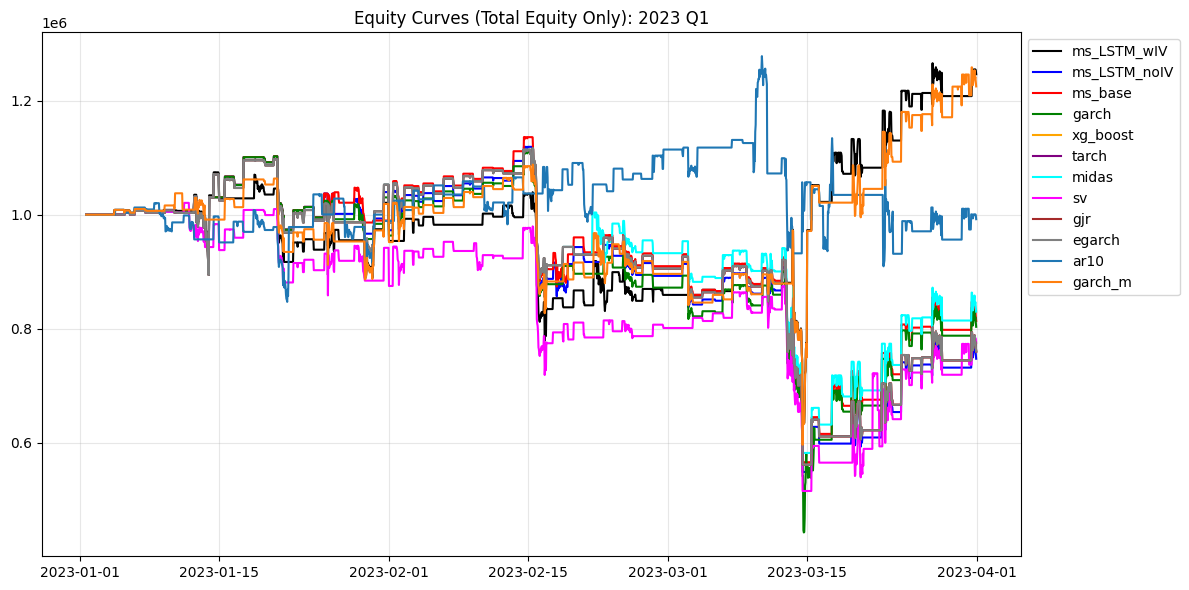

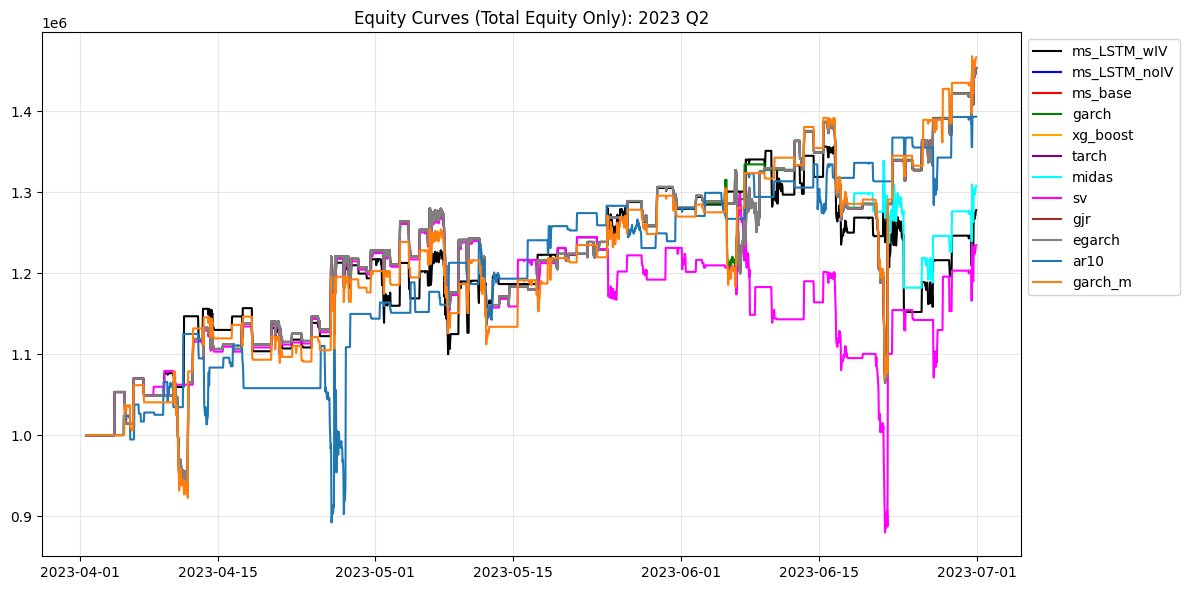

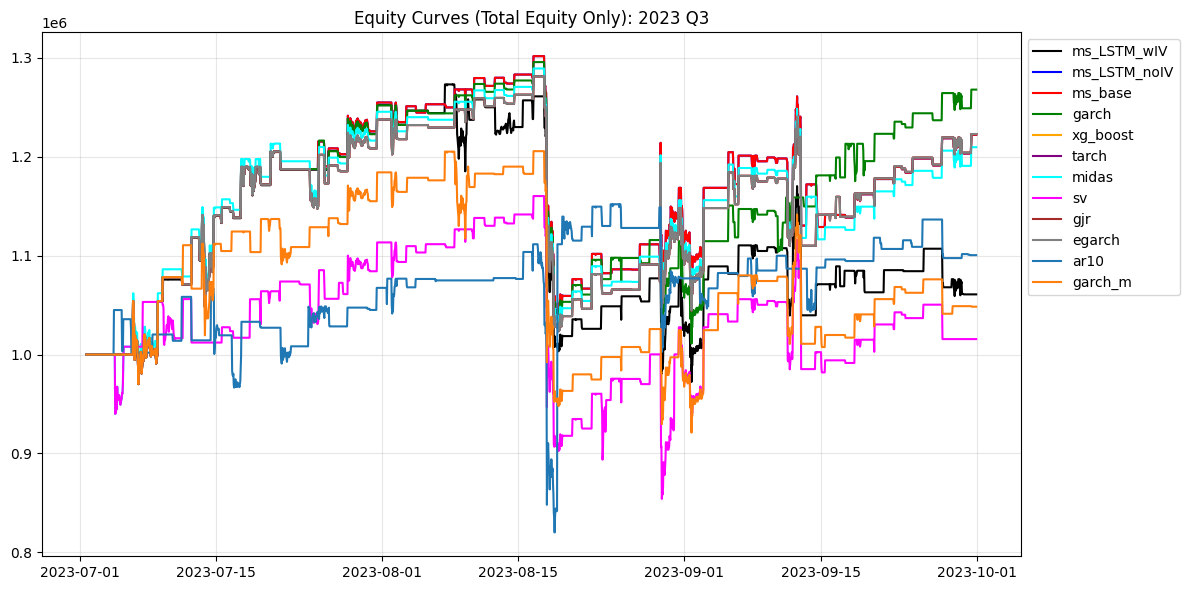

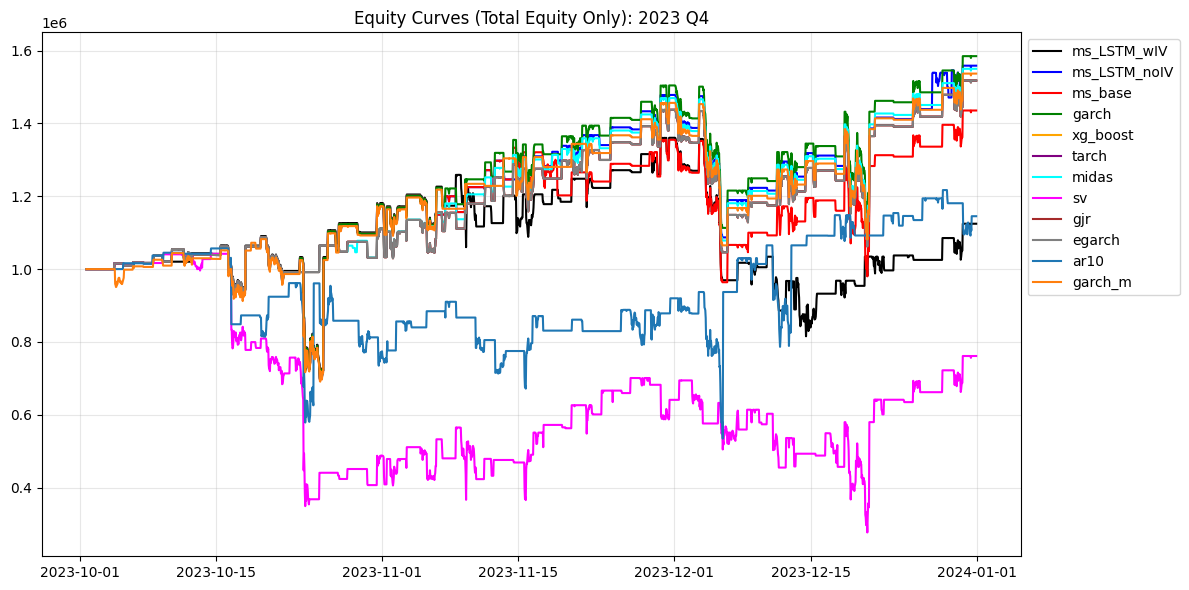

In [51]:
import matplotlib.pyplot as plt

# Define colors for consistency
colors = {
    "ms_LSTM_wIV": "black", "ms_LSTM_noIV": "blue", "ms_base": "red",
    "garch": "green", "xg_boost": "orange", "tarch": "purple",
    "midas": "cyan", "sv": "magenta", "gjr": "brown", "egarch": "gray"
}

for y in [2023]:
    for q in ["q1", "q2", "q3", "q4"]:
        if y not in outputs_by_year or q not in outputs_by_year[y]:
            continue
            
        plt.figure(figsize=(12, 6))
        plot_exists = False
        
        for model_name in models_to_test:
            var_name = f"{model_name}_{str(y)[2:]}_{q}"
            
            if var_name in globals():
                data = globals()[var_name]
                
                # Extract only the 'equity' column
                try:
                    # If it's a DataFrame
                    equity_curve = data['equity']
                except (TypeError, KeyError, IndexError):
                    # Fallback if it's a list/tuple of (equity, cash, options)
                    equity_curve = [x[0] for x in data] if isinstance(data[0], (list, tuple)) else data
                
                if len(equity_curve) > 0:
                    plt.plot(equity_curve, label=model_name, color=colors.get(model_name))
                    plot_exists = True
        
        if plot_exists:
            plt.title(f"Equity Curves (Total Equity Only): {y} {q.upper()}")
            plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            plt.close()

### save

In [52]:
# Save backtest results.
import pickle

data_to_dump = {
    # Q1 2023
    "ms_LSTM_wIV_23_q1": ms_LSTM_wIV_23_q1, "ms_LSTM_noIV_23_q1": ms_LSTM_noIV_23_q1,
    "ms_base_23_q1": ms_base_23_q1, "garch_23_q1": garch_23_q1,
    "xg_boost_23_q1": xg_boost_23_q1, "tarch_23_q1": tarch_23_q1,
    "midas_23_q1": midas_23_q1, "sv_23_q1": sv_23_q1,
    "gjr_23_q1": gjr_23_q1, "egarch_23_q1": egarch_23_q1,

    # Q2 2023
    "ms_LSTM_wIV_23_q2": ms_LSTM_wIV_23_q2, "ms_LSTM_noIV_23_q2": ms_LSTM_noIV_23_q2,
    "ms_base_23_q2": ms_base_23_q2, "garch_23_q2": garch_23_q2,
    "xg_boost_23_q2": xg_boost_23_q2, "tarch_23_q2": tarch_23_q2,
    "midas_23_q2": midas_23_q2, "sv_23_q2": sv_23_q2,
    "gjr_23_q2": gjr_23_q2, "egarch_23_q2": egarch_23_q2,

    # Q3 2023
    "ms_LSTM_wIV_23_q3": ms_LSTM_wIV_23_q3, "ms_LSTM_noIV_23_q3": ms_LSTM_noIV_23_q3,
    "ms_base_23_q3": ms_base_23_q3, "garch_23_q3": garch_23_q3,
    "xg_boost_23_q3": xg_boost_23_q3, "tarch_23_q3": tarch_23_q3,
    "midas_23_q3": midas_23_q3, "sv_23_q3": sv_23_q3,
    "gjr_23_q3": gjr_23_q3, "egarch_23_q3": egarch_23_q3,

    # Q4 2023
    "ms_LSTM_wIV_23_q4": ms_LSTM_wIV_23_q4, "ms_LSTM_noIV_23_q4": ms_LSTM_noIV_23_q4,
    "ms_base_23_q4": ms_base_23_q4, "garch_23_q4": garch_23_q4,
    "xg_boost_23_q4": xg_boost_23_q4, "tarch_23_q4": tarch_23_q4,
    "midas_23_q4": midas_23_q4, "sv_23_q4": sv_23_q4,
    "gjr_23_q4": gjr_23_q4, "egarch_23_q4": egarch_23_q4,
}

# Dump to file
with open('../strategy_outputs/2022_2025/07_30/backtest_results_2023.pkl', 'wb') as f:
    pickle.dump(data_to_dump, f)

### Testing Strategy 07_30 (2024)

In [53]:
# Hourly data
d_btc = pd.read_parquet("../data/rawData/btc_underlying_minutely_2024.parquet")
d_btc.set_index(pd.to_datetime(d_btc["date_time"]), inplace = True)

df = pd.read_parquet("../data/rawData/derivative_data_2024.parquet")

### 2024

In [54]:
market = Market(df,d_btc, starting_cash = 1000000)

In [55]:
from tqdm.auto import tqdm

# List of models to backtest
models_to_test = [
    "ms_LSTM_wIV", "ms_LSTM_noIV", "ms_base", "garch",
    "xg_boost", "tarch", "midas", "sv", "gjr", "egarch",
    "ar10", "garch_m"
]

strategy_results = {}

# Hardcoded for 2024 only
target_years = [2024]
total_runs = len(target_years) * 4 * len(models_to_test)
pbar = tqdm(total=total_runs, desc="Backtesting 2023")

for y in target_years:
    if y not in outputs_by_year:
        print(f"Year {y} not found in outputs_by_year.")
        pbar.update(4 * len(models_to_test))
        continue
        
    for q in ["q1", "q2", "q3", "q4"]:
        if q not in outputs_by_year[y] or outputs_by_year[y][q] is None:
            pbar.update(len(models_to_test))
            continue
            
        for model_name in models_to_test:
            pbar.set_description(f"Processing {y} {q} | {model_name}")
            
            if model_name not in outputs_by_year[y][q].columns:
                pbar.update(1)
                continue
            
            market = Market(df, d_btc, starting_cash=1000000)

            try:
                execute_trading_strategy(
                    bt_year=y, 
                    bt_quarter=q, 
                    model=model_name, 
                    outputs_by_year=outputs_by_year, 
                    market=market,
                    expiry_days = 30,
                    hold_days = 7
                )

                history_key = f"{model_name}_{str(y)[2:]}_{q}"
                equity_curve = market.get_equity_history()
                
                strategy_results[history_key] = equity_curve
                globals()[history_key] = equity_curve
                
            except Exception as e:
                print(f"\nError on {y} {q} model {model_name}: {e}")
            
            pbar.update(1)

pbar.close()
print("\nExecution Finished for 2025.")

Processing 2024 q1 | ms_LSTM_wIV:   0%|          | 0/48 [00:00<?, ?it/s]

Liquidate this option: (45000.0, Timestamp('2024-01-08 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (43500.0, Timestamp('2024-01-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (43500.0, Timestamp('2024-01-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (45000.0, Timestamp('2024-01-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (43250.0, Timestamp('2024-01-10 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (45000.0, Timestamp('2024-01-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (43250.0, Timestamp('2024-01-10 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (45000.0, Timestamp('2024-01-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (43250.0, Timestamp('2024-01-10 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (45000.0, Timestamp('2024-01-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (45000.0, Timestamp('2024-0

Processing 2024 q1 | ms_LSTM_noIV:   2%|▏         | 1/48 [08:04<6:19:27, 484.41s/it]

Liquidate this option: (44250.0, Timestamp('2024-01-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (43250.0, Timestamp('2024-01-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (43250.0, Timestamp('2024-01-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (43250.0, Timestamp('2024-01-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (45000.0, Timestamp('2024-01-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (43250.0, Timestamp('2024-01-10 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (45000.0, Timestamp('2024-01-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (43250.0, Timestamp('2024-01-10 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (45000.0, Timestamp('2024-01-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (43250.0, Timestamp('2024-01-10 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (45000.0, Timestamp('2024-0

Processing 2024 q1 | ms_base:   4%|▍         | 2/48 [16:26<6:19:25, 494.90s/it]     

...

Liquidate this option: (64000.0, Timestamp('2024-10-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (62500.0, Timestamp('2024-10-10 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (64000.0, Timestamp('2024-10-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (64000.0, Timestamp('2024-10-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (64000.0, Timestamp('2024-10-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (64000.0, Timestamp('2024-10-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (63500.0, Timestamp('2024-10-12 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (59500.0, Timestamp('2024-10-12 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (63500.0, Timestamp('2024-10-16 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (62000.0, Timestamp('2024-10-16 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (63500.0, Timestamp('2024-1

Processing 2024 q4 | garch_m:  98%|█████████▊| 47/48 [6:26:33<08:19, 499.99s/it]

Liquidate this option: (62500.0, Timestamp('2024-10-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (61000.0, Timestamp('2024-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (62500.0, Timestamp('2024-10-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (61000.0, Timestamp('2024-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (61000.0, Timestamp('2024-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (61000.0, Timestamp('2024-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (64000.0, Timestamp('2024-10-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (62500.0, Timestamp('2024-10-10 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (64000.0, Timestamp('2024-10-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (64000.0, Timestamp('2024-10-10 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (64000.0, Timestamp('2024-1

Processing 2024 q4 | garch_m: 100%|██████████| 48/48 [6:35:07<00:00, 493.90s/it]


Execution Finished for 2025.


### Equity Line 07_30 (2024)

In [133]:
equity_by_year = {}

for y in target_years:
    equity_by_year[y] = {}
    for q in ["q1", "q2", "q3", "q4"]:
        equity_by_year[y][q] = {}

        if y not in outputs_by_year or q not in outputs_by_year[y]:
            continue

        for model_name in models_to_test:
            history_key = f"{model_name}_{str(y)[2:]}_{q}"
            if history_key in strategy_results:
                equity_by_year[y][q][model_name] = strategy_results[history_key]



In [ ]:
# pickle.dump(equity_by_year, open("../strategy_outputs/2022_2025/07_30/equity_by_year_2024.pkl", "wb"))

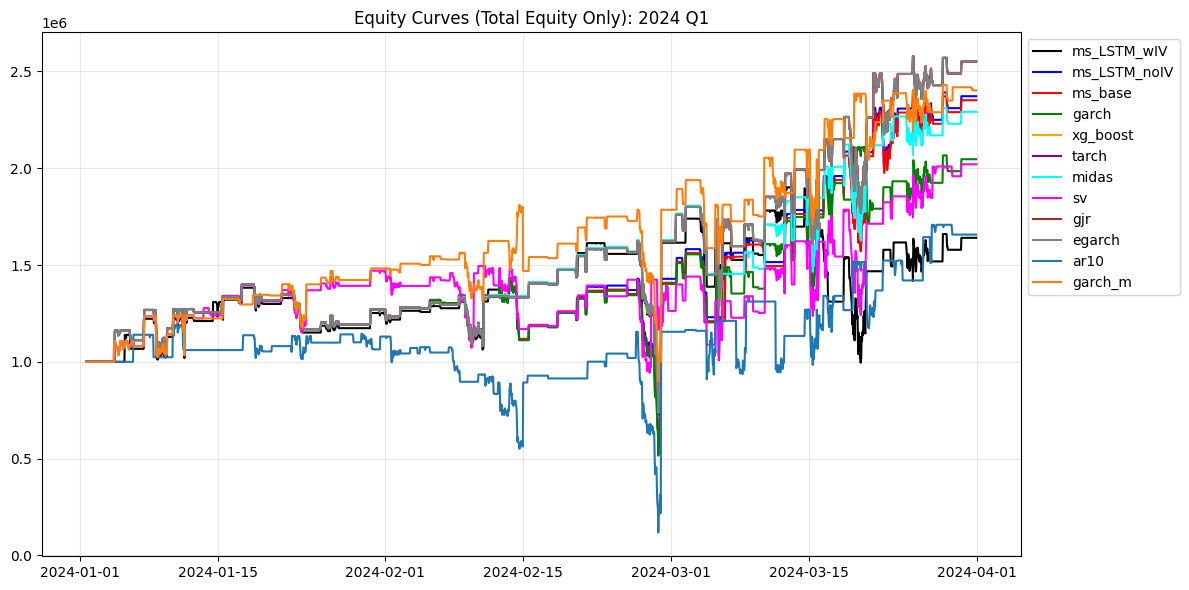

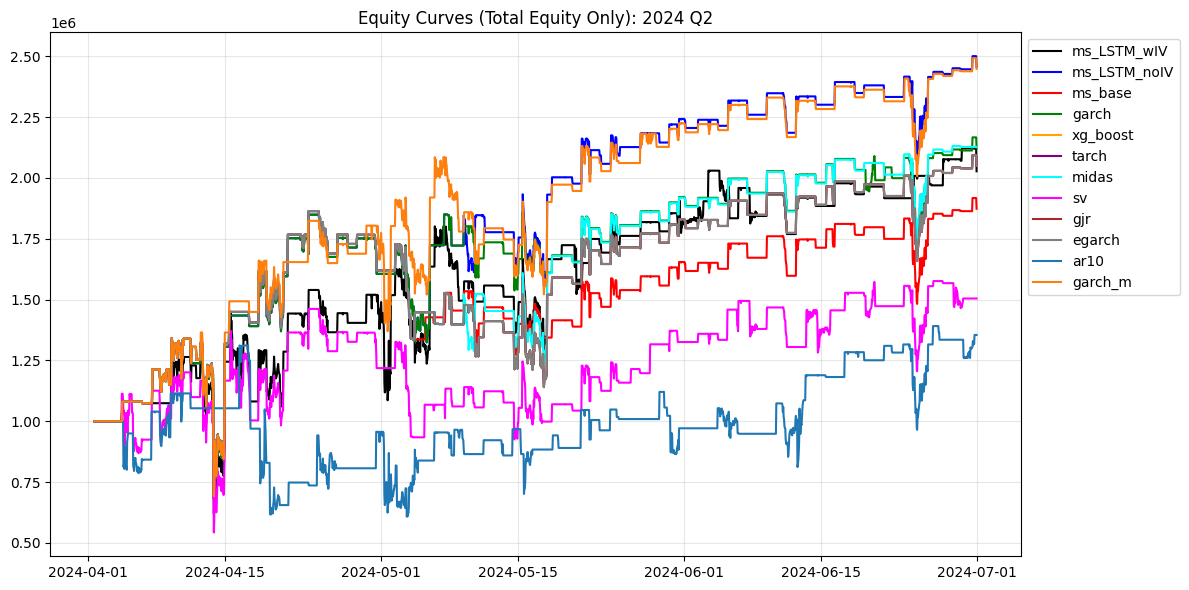

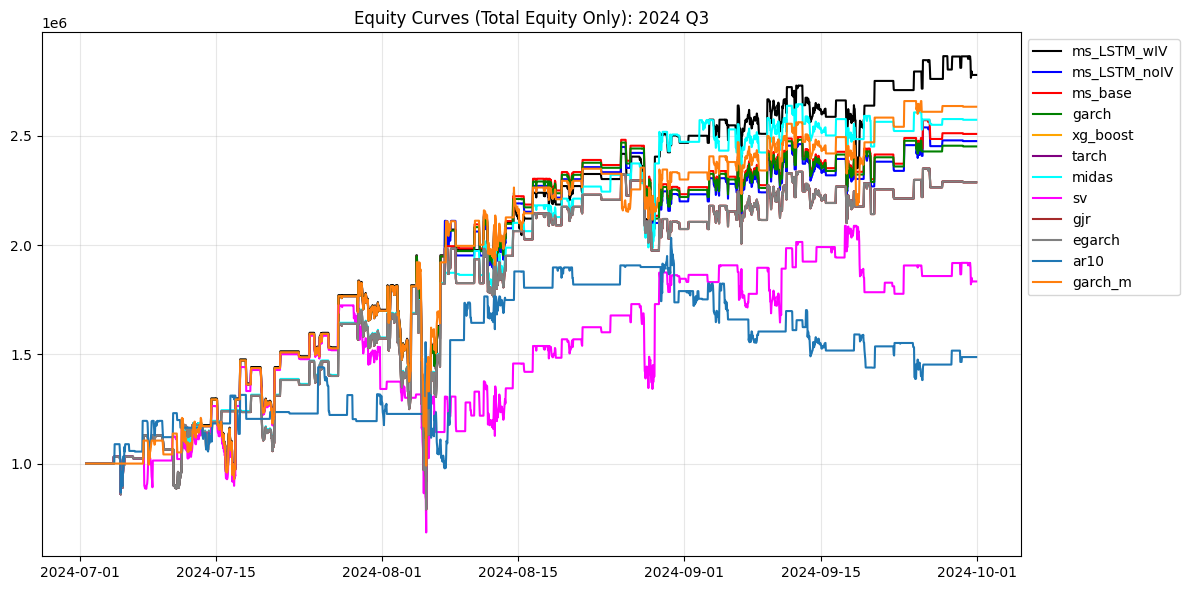

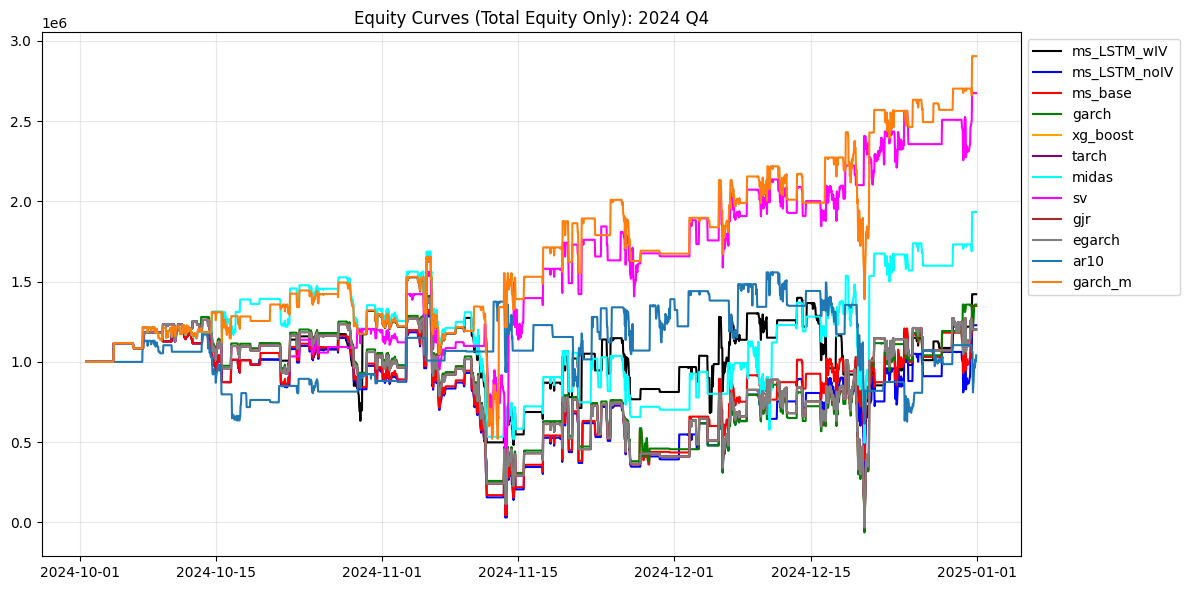

In [59]:
import matplotlib.pyplot as plt

# Define colors for consistency
colors = {
    "ms_LSTM_wIV": "black", "ms_LSTM_noIV": "blue", "ms_base": "red",
    "garch": "green", "xg_boost": "orange", "tarch": "purple",
    "midas": "cyan", "sv": "magenta", "gjr": "brown", "egarch": "gray"
}

for y in [2024]:
    for q in ["q1", "q2", "q3", "q4"]:
        if y not in outputs_by_year or q not in outputs_by_year[y]:
            continue
            
        plt.figure(figsize=(12, 6))
        plot_exists = False
        
        for model_name in models_to_test:
            var_name = f"{model_name}_{str(y)[2:]}_{q}"
            
            if var_name in globals():
                data = globals()[var_name]
                
                # Extract only the 'equity' column
                try:
                    # If it's a DataFrame
                    equity_curve = data['equity']
                except (TypeError, KeyError, IndexError):
                    # Fallback if it's a list/tuple of (equity, cash, options)
                    equity_curve = [x[0] for x in data] if isinstance(data[0], (list, tuple)) else data
                
                if len(equity_curve) > 0:
                    plt.plot(equity_curve, label=model_name, color=colors.get(model_name))
                    plot_exists = True
        
        if plot_exists:
            plt.title(f"Equity Curves (Total Equity Only): {y} {q.upper()}")
            plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            plt.close()

### save

In [57]:
# Save backtest results.
import pickle

data_to_dump = {
    # Q1 2024
    "ms_LSTM_wIV_24_q1": ms_LSTM_wIV_24_q1, "ms_LSTM_noIV_24_q1": ms_LSTM_noIV_24_q1,
    "ms_base_24_q1": ms_base_24_q1, "garch_24_q1": garch_24_q1,
    "xg_boost_24_q1": xg_boost_24_q1, "tarch_24_q1": tarch_24_q1,
    "midas_24_q1": midas_24_q1, "sv_24_q1": sv_24_q1,
    "gjr_24_q1": gjr_24_q1, "egarch_24_q1": egarch_24_q1,

    # Q2 2024
    "ms_LSTM_wIV_24_q2": ms_LSTM_wIV_24_q2, "ms_LSTM_noIV_24_q2": ms_LSTM_noIV_24_q2,
    "ms_base_24_q2": ms_base_24_q2, "garch_24_q2": garch_24_q2,
    "xg_boost_24_q2": xg_boost_24_q2, "tarch_24_q2": tarch_24_q2,
    "midas_24_q2": midas_24_q2, "sv_24_q2": sv_24_q2,
    "gjr_24_q2": gjr_24_q2, "egarch_24_q2": egarch_24_q2,

    # Q3 2024
    "ms_LSTM_wIV_24_q3": ms_LSTM_wIV_24_q3, "ms_LSTM_noIV_24_q3": ms_LSTM_noIV_24_q3,
    "ms_base_24_q3": ms_base_24_q3, "garch_24_q3": garch_24_q3,
    "xg_boost_24_q3": xg_boost_24_q3, "tarch_24_q3": tarch_24_q3,
    "midas_24_q3": midas_24_q3, "sv_24_q3": sv_24_q3,
    "gjr_24_q3": gjr_24_q3, "egarch_24_q3": egarch_24_q3,

    # Q4 2024
    "ms_LSTM_wIV_24_q4": ms_LSTM_wIV_24_q4, "ms_LSTM_noIV_24_q4": ms_LSTM_noIV_24_q4,
    "ms_base_24_q4": ms_base_24_q4, "garch_24_q4": garch_24_q4,
    "xg_boost_24_q4": xg_boost_24_q4, "tarch_24_q4": tarch_24_q4,
    "midas_24_q4": midas_24_q4, "sv_24_q4": sv_24_q4,
    "gjr_24_q4": gjr_24_q4, "egarch_24_q4": egarch_24_q4,
}

# Dump to file
with open('../strategy_outputs/2022_2025/07_30/backtest_results_2024.pkl', 'wb') as f:
    pickle.dump(data_to_dump, f)

### OOS Strategy 07_30 (2025)

In [136]:
# Hourly data
d_btc = pd.read_parquet("../data/rawData/btc_underlying_minutely_2025.parquet")
d_btc.set_index(pd.to_datetime(d_btc["date_time"]), inplace = True)

df = pd.read_parquet("../data/rawData/derivative_data_2025.parquet")

### 2025

In [ ]:
# Hourly data
d_btc = pd.read_parquet("../data/rawData/btc_underlying_minutely_2025.parquet")
d_btc.set_index(pd.to_datetime(d_btc["date_time"]), inplace = True)

df = pd.read_parquet("../data/rawData/derivative_data_2025.parquet")

In [137]:
market = Market(df,d_btc, starting_cash = 1000000)

In [ ]:
from tqdm.auto import tqdm

# List of models to backtest
models_to_test = [
    "ms_LSTM_wIV", "ms_LSTM_noIV", "ms_base", "garch",
    "xg_boost", "tarch", "midas", "sv", "gjr", "egarch",
    "ar10", "garch_m"
]

strategy_results = {}

# Hardcoded for 2025 only
target_years = [2025]
total_runs = len(target_years) * 4 * len(models_to_test)
pbar = tqdm(total=total_runs, desc="Backtesting 2023")

for y in target_years:
    if y not in outputs_by_year:
        print(f"Year {y} not found in outputs_by_year.")
        pbar.update(4 * len(models_to_test))
        continue
        
    for q in ["q1", "q2", "q3", "q4"]:
        if q not in outputs_by_year[y] or outputs_by_year[y][q] is None:
            pbar.update(len(models_to_test))
            continue
            
        for model_name in models_to_test:
            pbar.set_description(f"Processing {y} {q} | {model_name}")
            
            if model_name not in outputs_by_year[y][q].columns:
                pbar.update(1)
                continue
            
            market = Market(df, d_btc, starting_cash=1000000)

            try:
                execute_trading_strategy(
                    bt_year=y, 
                    bt_quarter=q, 
                    model=model_name, 
                    outputs_by_year=outputs_by_year, 
                    market=market,
                    expiry_days = 30,
                    hold_days = 7
                )

                history_key = f"{model_name}_{str(y)[2:]}_{q}"
                equity_curve = market.get_equity_history()
                
                strategy_results[history_key] = equity_curve
                globals()[history_key] = equity_curve
                
            except Exception as e:
                print(f"\nError on {y} {q} model {model_name}: {e}")
            
            pbar.update(1)

pbar.close()
print("\nExecution Finished for 2025.")

Processing 2025 q1 | ms_LSTM_wIV:   0%|          | 0/48 [00:00<?, ?it/s]

Liquidate this option: (101000.0, Timestamp('2025-01-09 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (97000.0, Timestamp('2025-01-09 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (101000.0, Timestamp('2025-01-09 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (97000.0, Timestamp('2025-01-09 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (98000.0, Timestamp('2025-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (94000.0, Timestamp('2025-01-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (96000.0, Timestamp('2025-01-13 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (93000.0, Timestamp('2025-01-13 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (93000.0, Timestamp('2025-01-13 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (93000.0, Timestamp('2025-01-13 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (93000.0, Timestamp('2025

Processing 2025 q1 | ms_LSTM_noIV:   2%|▏         | 1/48 [08:54<6:58:26, 534.17s/it]

Liquidate this option: (101000.0, Timestamp('2025-01-09 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (97000.0, Timestamp('2025-01-09 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (101000.0, Timestamp('2025-01-09 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (97000.0, Timestamp('2025-01-09 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (98000.0, Timestamp('2025-01-11 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (94000.0, Timestamp('2025-01-11 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (99000.0, Timestamp('2025-01-13 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (91000.0, Timestamp('2025-01-13 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (99000.0, Timestamp('2025-01-13 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (91000.0, Timestamp('2025-01-13 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (96000.0, Timestamp('2025

Processing 2025 q1 | ms_base:   4%|▍         | 2/48 [17:24<6:38:52, 520.28s/it]     

...

Liquidate this option: (130000.0, Timestamp('2025-10-08 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (118000.0, Timestamp('2025-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (118000.0, Timestamp('2025-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (118000.0, Timestamp('2025-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (118000.0, Timestamp('2025-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (118000.0, Timestamp('2025-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (118000.0, Timestamp('2025-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (118000.0, Timestamp('2025-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (118000.0, Timestamp('2025-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (118000.0, Timestamp('2025-10-08 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (118000.0, Timest

Processing 2025 q4 | garch_m:  98%|█████████▊| 47/48 [7:33:35<10:09, 609.11s/it]

Liquidate this option: (124000.0, Timestamp('2025-10-07 00:00:00+0000', tz='UTC'), 'C', 'sell')
Liquidate this option: (119000.0, Timestamp('2025-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (119000.0, Timestamp('2025-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (119000.0, Timestamp('2025-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (119000.0, Timestamp('2025-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (119000.0, Timestamp('2025-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (119000.0, Timestamp('2025-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (119000.0, Timestamp('2025-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (119000.0, Timestamp('2025-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (119000.0, Timestamp('2025-10-07 00:00:00+0000', tz='UTC'), 'P', 'sell')
Liquidate this option: (119000.0, Timest

Processing 2025 q4 | garch_m: 100%|██████████| 48/48 [7:43:45<00:00, 579.69s/it]


Execution Finished for 2025.


## 01_30 performance check only.

### Equity Line (2025)

In [ ]:

pickle.dump(equity_by_year, open("../strategy_outputs/2022_2025/01_30/equity_by_year_2025.pkl", "wb"))

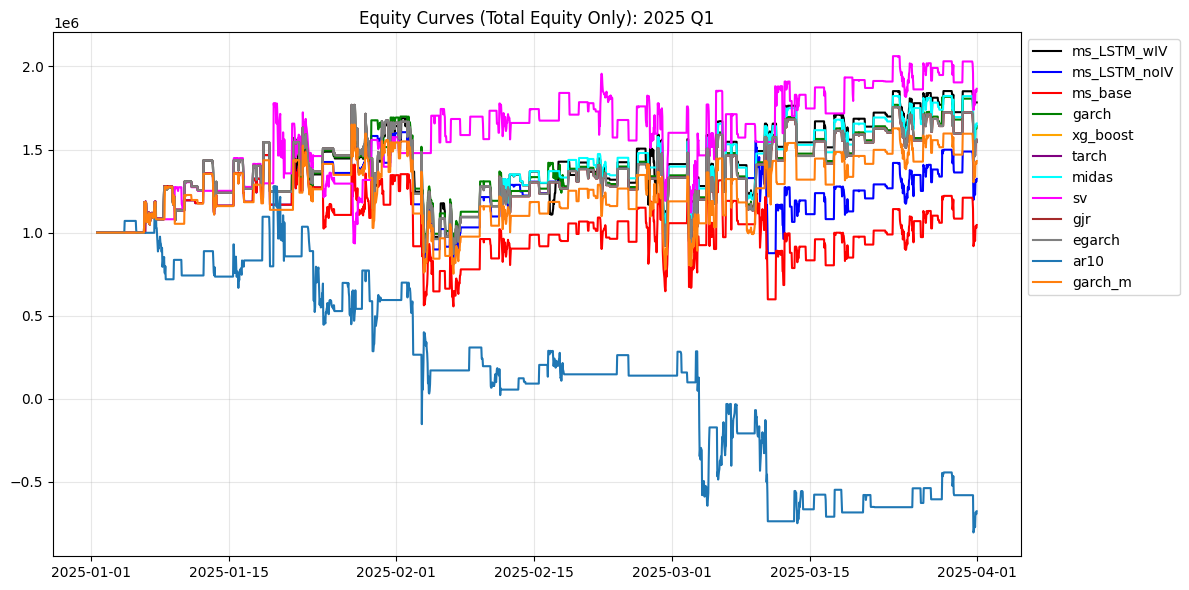

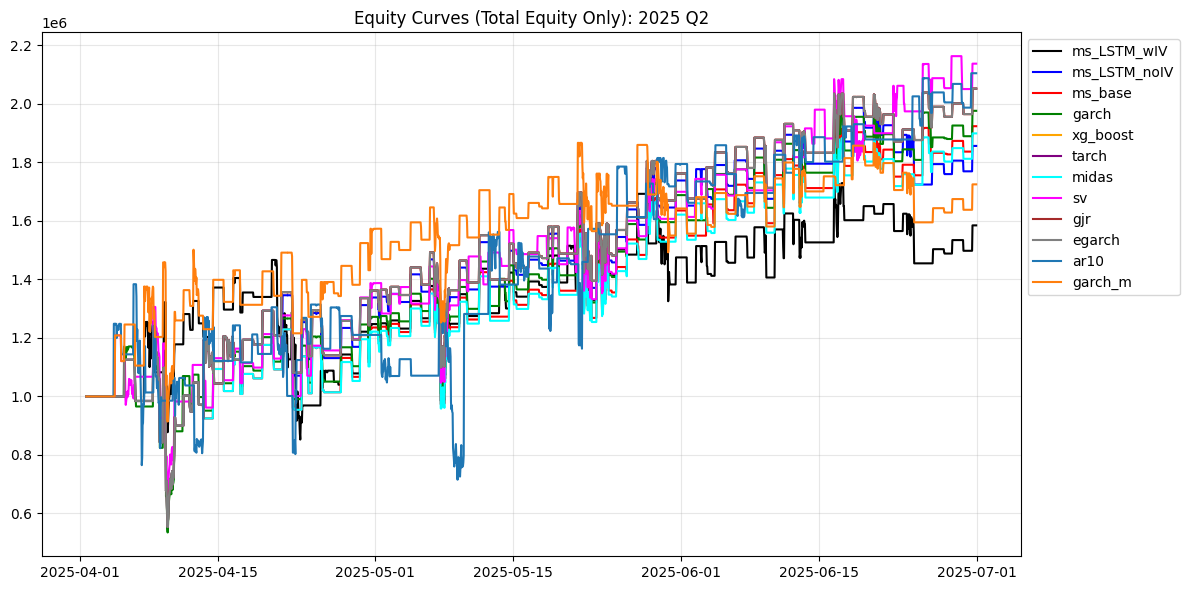

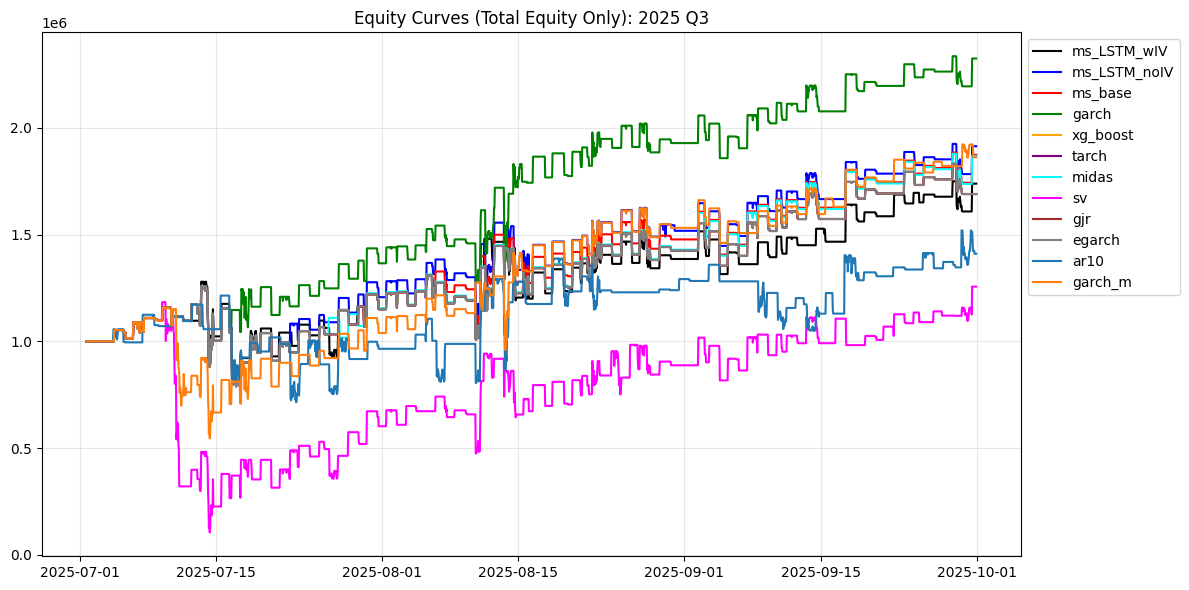

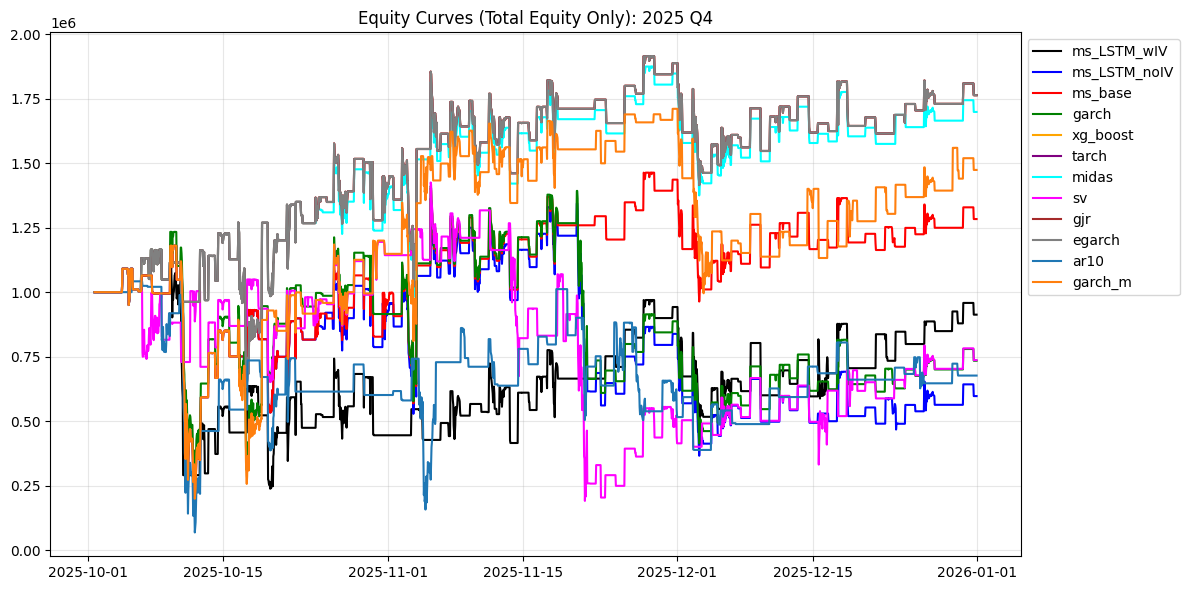

In [145]:
import matplotlib.pyplot as plt

# Define colors for consistency
colors = {
    "ms_LSTM_wIV": "black", "ms_LSTM_noIV": "blue", "ms_base": "red",
    "garch": "green", "xg_boost": "orange", "tarch": "purple",
    "midas": "cyan", "sv": "magenta", "gjr": "brown", "egarch": "gray"
}

for y in [2025]:
    for q in ["q1", "q2", "q3", "q4"]:
        if y not in outputs_by_year or q not in outputs_by_year[y]:
            continue
            
        plt.figure(figsize=(12, 6))
        plot_exists = False
        
        for model_name in models_to_test:
            var_name = f"{model_name}_{str(y)[2:]}_{q}"
            
            if var_name in globals():
                data = globals()[var_name]
                
                # Extract only the 'equity' column
                try:
                    # If it's a DataFrame
                    equity_curve = data['equity']
                except (TypeError, KeyError, IndexError):
                    # Fallback if it's a list/tuple of (equity, cash, options)
                    equity_curve = [x[0] for x in data] if isinstance(data[0], (list, tuple)) else data
                
                if len(equity_curve) > 0:
                    plt.plot(equity_curve, label=model_name, color=colors.get(model_name))
                    plot_exists = True
        
        if plot_exists:
            plt.title(f"Equity Curves (Total Equity Only): {y} {q.upper()}")
            plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            plt.close()

### end 